# <span style = "color:green"> Data Aggregation and Preparation </span>

### Step 1: Download the IEEE 118-Bus System

methodology citation: Donti, P., Amos, B., & Kolter, J. Z. (2017). Task-based End-to-End Model Learning in Stochastic Optimization. Advances in Neural Information Processing Systems (NeurIPS), 30. (This paper is foundational for bridging neural network load predictions directly with downstream non-linear grid optimization).

In [176]:
import urllib.request
import pandas as pd
import re

# 1. Download the file
url = "https://raw.githubusercontent.com/power-grid-lib/pglib-opf/master/pglib_opf_case118_ieee.m"
filename = "pglib_opf_case118_ieee.m"
print("Downloading IEEE 118-bus case...")
urllib.request.urlretrieve(url, filename)

def parse_matpower_matrix(filepath, matrix_name):
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Use regex to find the block of text between 'mpc.matrix_name = [' and '];'
    pattern = rf"mpc\.{matrix_name}\s*=\s*\[(.*?)\];"
    match = re.search(pattern, content, re.DOTALL)
        
    data = []
    # Read line by line, ignoring MATLAB comments (%)
    for line in match.group(1).strip().split('\n'):
        # Strip comments, remove MATLAB semicolons, and clean whitespace
        clean_line = line.split('%')[0].replace(';', '').strip()
            
        row = [float(x) for x in clean_line.split()]
        data.append(row)
        
    return pd.DataFrame(data)

# =====================================================================
# 3. EXTRACT THE DC-OPF DATA
# =====================================================================

# --- BUS DATA ---
# Col 0: Bus ID | Col 2: Active Demand (Pd) | Col 3: Reactive Demand (Qd)
# Col 7: Voltage magnitude setpoint (Vm) | Col 11: Vmax | Col 12: Vmin
bus_df = parse_matpower_matrix(filename, 'bus')
nodal_demand = bus_df[[0, 2]].rename(columns={0: 'bus_id', 2: 'Pd_mw'})
# AC additions: reactive demand and voltage bounds
nodal_demand_q = bus_df[[0, 3]].rename(columns={0: 'bus_id', 3: 'Qd_mvar'})
bus_vmax = bus_df[[0, 11]].rename(columns={0: 'bus_id', 11: 'Vmax'})
bus_vmin = bus_df[[0, 12]].rename(columns={0: 'bus_id', 12: 'Vmin'})

# --- GENERATOR DATA (WITH FIXED ALPHAS) ---
# Col 0: Bus ID | Col 1: Base Pg | Col 3: Qmax | Col 4: Qmin | Col 8: Pmax | Col 9: Pmin
gen_df = parse_matpower_matrix(filename, 'gen')
gen_limits = gen_df[[0, 1, 8, 9]].rename(columns={
    0: 'bus_id', 
    1: 'Pg_base_mw', 
    8: 'Pmax_mw', 
    9: 'Pmin_mw'
})
# AC additions: reactive power limits
gen_limits['Qmax_mvar'] = gen_df[3].values
gen_limits['Qmin_mvar'] = gen_df[4].values

# 1. Calculate available headroom for each generator
gen_limits['headroom_mw'] = gen_limits['Pmax_mw'] - gen_limits['Pg_base_mw']

# 2. Safety clip: Ensure no negative headroom (in case of MATPOWER rounding quirks)
gen_limits['headroom_mw'] = gen_limits['headroom_mw'].clip(lower=0.0)

# 3. Calculate the fixed alpha (Participation Factor)
total_headroom = gen_limits['headroom_mw'].sum()

if total_headroom > 0:
    gen_limits['alpha_fixed'] = gen_limits['headroom_mw'] / total_headroom
else:
    # Fallback if no headroom exists system-wide (unlikely in standard cases)
    gen_limits['alpha_fixed'] = 1.0 / len(gen_limits)

print("Fixed Alpha values calculated successfully. Top 5 contributors:")
print(gen_limits[['bus_id', 'Pg_base_mw', 'Pmax_mw', 'alpha_fixed']].sort_values('alpha_fixed', ascending=False).head())

# --- BRANCH DATA ---
# Col 0: From Bus | Col 1: To Bus | Col 2: Resistance (r) | Col 3: Reactance (x)
# Col 4: Charging susceptance (b_c) | Col 5: Rate A (MW limit)
branch_df = parse_matpower_matrix(filename, 'branch')
branch_data = branch_df[[0, 1, 3, 5]].rename(columns={0: 'from_bus', 1: 'to_bus', 3: 'x_reactance', 5: 'thermal_limit_mw'})
# AC additions: resistance and charging susceptance (for full pi-model)
branch_data['r_resistance']      = branch_df[2].values
branch_data['b_charging']        = branch_df[4].values
branch_data['B_susceptance']     = 1.0 / branch_data['x_reactance']
# Impedance magnitude for AC admittance computation
branch_data['z_mag2'] = branch_data['r_resistance']**2 + branch_data['x_reactance']**2
# Series admittance: g = r/|z|^2,  b = -x/|z|^2
branch_data['g_series'] = branch_data['r_resistance']  / branch_data['z_mag2']
branch_data['b_series'] = -branch_data['x_reactance'] / branch_data['z_mag2']

# --- GENERATOR COSTS ---
# Col 3: Number of coefficients | Col 5: Linear cost (c1) | Col 6: Constant cost (c0)
# Note: PGLib 118 uses linear costs, so n=2 (represented by 2 coefficients)
gencost_df = parse_matpower_matrix(filename, 'gencost')
gen_costs = gencost_df[[5, 6]].rename(columns={5: 'cost_linear', 6: 'cost_constant'})

print("Extraction Successful! Here is a sample of your branch data:")
print(branch_data.head())
print(f"\nAC data extracted: Q limits for {len(gen_limits)} gens, "
      f"resistance for {len(branch_data)} branches, "
      f"voltage bounds for {len(bus_df)} buses")


Fixed Alpha values calculated successfully. Top 5 contributors:
    bus_id  Pg_base_mw  Pmax_mw  alpha_fixed
29    69.0       591.0   1182.0     0.181427
28    66.0       392.0    784.0     0.120338
44   100.0       326.5    653.0     0.100230
39    89.0       318.5    637.0     0.097774
36    80.0       254.5    509.0     0.078127
Extraction Successful! Here is a sample of your branch data:
   from_bus  to_bus  x_reactance  thermal_limit_mw  r_resistance  b_charging  \
0       1.0     2.0      0.09990             151.0       0.03030     0.02540   
1       1.0     3.0      0.04240             151.0       0.01290     0.01082   
2       4.0     5.0      0.00798             176.0       0.00176     0.00210   
3       3.0     5.0      0.10800             175.0       0.02410     0.02840   
4       5.0     6.0      0.05400             176.0       0.01190     0.01426   

   B_susceptance    z_mag2   g_series    b_series  
0      10.010010  0.010898   2.780301   -9.166735  
1      23.584906  0.

### 2. Download Demand Data

citation: A novel probabilistic gradient boosting model withmulti-approachfeature selection and iterative seasonal trend decomposition for short-term load forecasting
Priyesh Saini∗, S.K. Parida

In [177]:
import os
import pandas as pd
import numpy as np
import requests
import io
import time

START = "2019-01-01"
END   = "2023-12-31"

WX_CACHE = "wx_cache_jfk.csv"

# CAISO system load is replaced by ARPA-E PERFORM NYISO data — see spatial demand cell below.
if False:
    from gridstatus import CAISO
    iso = CAISO()
    load = iso.get_load(
        start=pd.Timestamp(START, tz="US/Pacific"),
        end=pd.Timestamp(END,   tz="US/Pacific"),
    )
    load = load.rename(columns={"Load": "load_mw", "Time": "timestamp"})
    load["timestamp"] = (pd.to_datetime(load["timestamp"])
                          .dt.tz_convert("US/Pacific")
                          .dt.tz_localize(None))
    load["timestamp"] = load["timestamp"].dt.round("5min")
    load = (load[["timestamp", "load_mw"]]
            .drop_duplicates("timestamp")
            .sort_values("timestamp")
            .set_index("timestamp"))

# =====================================================================
# JFK ASOS: Chunked 5-minute temperature + RH (2019-2023)
# =====================================================================
def fetch_asos_chunk(start_dt, end_dt, retries=5):
    """Fetches a small time chunk from IEM with automatic exponential backoff."""
    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"
        f"?station=JFK&data=tmpf,relh"
        f"&year1={start_dt.year}&month1={start_dt.month}&day1={start_dt.day}"
        f"&year2={end_dt.year}&month2={end_dt.month}&day2={end_dt.day}"
        "&tz=America/New_York&format=onlycomma&latlon=no&missing=empty"
    )
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

    for attempt in range(retries):
        try:
            response = requests.get(url, headers=headers, timeout=30)
            if response.status_code == 200:
                return pd.read_csv(io.StringIO(response.text), parse_dates=["valid"])
            elif response.status_code in [503, 429]:
                wait_time = 2 ** (attempt + 1) + 2
                print(f"  [!] HTTP {response.status_code}. Retrying in {wait_time}s...")
                time.sleep(wait_time)
            else:
                response.raise_for_status()
        except (requests.exceptions.ConnectionError,
                requests.exceptions.Timeout) as exc:
            wait_time = 2 ** (attempt + 1) + 2
            print(f"  [!] Network error on attempt {attempt + 1}: {exc}. Retrying in {wait_time}s...")
            time.sleep(wait_time)

    raise Exception(f"Failed to fetch {start_dt.date()} after {retries} retries.")


if os.path.exists(WX_CACHE):
    print(f"Loading cached weather data from {WX_CACHE}...")
    wx = pd.read_csv(WX_CACHE, index_col=0, parse_dates=True)
    print(f"Weather rows (JFK, from cache): {len(wx.dropna()):,}")
else:
    print("Fetching JFK weather data (2019-2023) in 30-day chunks...")

    date_chunks = pd.date_range(start=START, end=END, freq='30D').tolist()
    if pd.Timestamp(END) not in date_chunks:
        date_chunks.append(pd.Timestamp(END))

    wx_chunks = []
    for i in range(len(date_chunks) - 1):
        s = date_chunks[i]
        e = date_chunks[i+1]
        print(f"  -> Pulling chunk: {s.date()} to {e.date()}")
        chunk_df = fetch_asos_chunk(s, e)
        wx_chunks.append(chunk_df)
        time.sleep(3)

    wx = pd.concat(wx_chunks, ignore_index=True)
    wx = wx.drop_duplicates(subset=["valid"])
    wx = wx.rename(columns={"valid": "timestamp", "tmpf": "temp_f", "relh": "rh_pct"})
    wx["temperature"] = (wx["temp_f"] - 32) * 5/9

    T  = wx["temperature"]
    RH = wx["rh_pct"]
    wx["humidity"] = (6.112 * np.exp(17.67 * T / (T + 243.5)) * RH * 2.1674) / (273.15 + T)

    wx = wx[["timestamp", "temperature", "humidity"]].dropna()
    wx["timestamp"] = wx["timestamp"].dt.round("5min")
    wx = wx.groupby("timestamp").mean().sort_index()

    # Align to fixed 5-year 5-min grid (2019-2023)
    grid = pd.date_range(start="2019-01-01", end="2023-12-31 23:55", freq="5min")
    wx = wx.reindex(grid).interpolate("time", limit=12)

    wx.to_csv(WX_CACHE)
    print(f"\nWeather rows (JFK 2019-2023): {len(wx.dropna()):,}  — saved to {WX_CACHE}")


Loading cached weather data from wx_cache_jfk.csv...
Weather rows (JFK, from cache): 525,527


### 3. Data Aggregation and Scaling

In [178]:
import matplotlib.pyplot as plt

'''# 1. Calculate the 30-day rolling average
# 30 days = 30 * 288 (5-min intervals per day) = 8640
rolling_30d = df['load_mw'].rolling(window=8640, center=True).mean()

# 2. Plotting
plt.figure(figsize=(15, 5))

# Plot the raw 5-minute demand (made slightly transparent to let the trendline pop)
df['load_mw'].plot(
    color='#1f77b4', 
    linewidth=0.5, 
    alpha=0.5, 
    label='5-Min Demand'
)

# Plot the 30-Day Rolling Average Trendline
rolling_30d.plot(
    color='black',       # Strong contrasting color 
    linewidth=2.5,       # Thicker line to stand out over the blue density
    label='30-Day Average Trend'
)

# Format the chart
plt.title('System Power Demand with 30-Day Trendline')
plt.ylabel('Load (MW)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right') # Adds a key to identify the lines

plt.show()'''

"# 1. Calculate the 30-day rolling average\n# 30 days = 30 * 288 (5-min intervals per day) = 8640\nrolling_30d = df['load_mw'].rolling(window=8640, center=True).mean()\n\n# 2. Plotting\nplt.figure(figsize=(15, 5))\n\n# Plot the raw 5-minute demand (made slightly transparent to let the trendline pop)\ndf['load_mw'].plot(\n    color='#1f77b4', \n    linewidth=0.5, \n    alpha=0.5, \n    label='5-Min Demand'\n)\n\n# Plot the 30-Day Rolling Average Trendline\nrolling_30d.plot(\n    color='black',       # Strong contrasting color \n    linewidth=2.5,       # Thicker line to stand out over the blue density\n    label='30-Day Average Trend'\n)\n\n# Format the chart\nplt.title('System Power Demand with 30-Day Trendline')\nplt.ylabel('Load (MW)')\nplt.xlabel('Date')\nplt.grid(True, alpha=0.3)\nplt.legend(loc='upper right') # Adds a key to identify the lines\n\nplt.show()"

In [179]:
# df and scaling_factor are now built by the NYISO PERFORM spatial demand cell below.
# This cell is kept only for backward compatibility with CAISO-mode runs.
abs_max_scale = gen_limits['Pmax_mw'].sum() / nodal_demand['Pd_mw'].sum()

if 'load' in globals() and hasattr(load, 'index'):
    # CAISO legacy mode
    df = load.join(wx, how="inner").dropna()
    median_load = float(np.median(df['load_mw']))
    df['scaling_factor'] = df['load_mw'] / median_load
    exceedance_pct = (df['scaling_factor'] >= abs_max_scale).mean() * 100
    print(f"{exceedance_pct:.2f}% of time more power than gen can handle")
else:
    print("CAISO data not loaded — df will be built by the NYISO PERFORM cell.")

CAISO data not loaded — df will be built by the NYISO PERFORM cell.


In [180]:
## Identify Generator limits (system wide)
system_max = gen_limits['Pmax_mw'].sum()

safety_thresh = 1.06
max_scaling_factor = safety_thresh * system_max / nodal_demand['Pd_mw'].sum()


In [181]:
# Exceedance check — computed after df is built by the NYISO PERFORM cell below.


In [182]:
 ## Define Parameters
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

# -----------------------------------------------------------------------------
# 1. Build index maps and system data
# -----------------------------------------------------------------------------
bus_ids   = nodal_demand['bus_id'].astype(int).values
N_BUS     = len(bus_ids)
bus_idx   = {int(b): i for i, b in enumerate(bus_ids)}

gen_bus     = gen_limits['bus_id'].astype(int).values
gen_bus_idx = np.array([bus_idx[int(b)] for b in gen_bus])
Pg_min      = gen_limits['Pmin_mw'].values
Pg_max      = gen_limits['Pmax_mw'].values
c1          = gen_costs['cost_linear'].values
c0          = gen_costs['cost_constant'].values
N_GEN       = len(gen_bus)
from_idx = np.array([bus_idx[int(b)] for b in branch_data['from_bus']])
to_idx   = np.array([bus_idx[int(b)] for b in branch_data['to_bus']])
B_line   = branch_data['B_susceptance'].values
R_line   = branch_data['thermal_limit_mw'].values
N_LINE   = len(B_line)

SLACK  = 0
VOLL   = 10000.0
C_CURT = 1000.0

# -----------------------------------------------------------------------------
# 2. AC-OPF data (used only in stage-2 AC recourse evaluation)
# -----------------------------------------------------------------------------
# Generator reactive power limits (MVAr)
Qg_max = gen_limits['Qmax_mvar'].values.astype(float)
Qg_min = gen_limits['Qmin_mvar'].values.astype(float)

# Bus voltage bounds (p.u.) — IEEE 118 uses 0.94–1.06 for most buses
_v_max_ser = bus_vmax.set_index('bus_id').loc[bus_ids, 'Vmax']
_v_min_ser = bus_vmin.set_index('bus_id').loc[bus_ids, 'Vmin']
Vmax = _v_max_ser.values.astype(float)
Vmin = _v_min_ser.values.astype(float)
# Fallback: if any bounds are 0, replace with standard ±10%
Vmax = np.where(Vmax <= 0, 1.10, Vmax)
Vmin = np.where(Vmin <= 0, 0.90, Vmin)

# Reactive demand per bus (MVAr)
Qd_bus = nodal_demand_q.set_index('bus_id').loc[bus_ids, 'Qd_mvar'].values.astype(float)

# Branch AC admittance parameters
g_series  = branch_data['g_series'].values.astype(float)   # series conductance
b_series  = branch_data['b_series'].values.astype(float)   # series susceptance (negative)
b_shunt   = branch_data['b_charging'].values.astype(float) / 2.0  # half-line charging

# Apparent power rating (MVA) — use same thermal limit as DC for now
# S_line[l]^2 = P[l]^2 + Q[l]^2 <= R_line[l]^2
S_rate = R_line.copy()

print(f"AC parameters loaded:")
print(f"  Voltage bounds: [{Vmin.min():.3f}, {Vmax.max():.3f}] p.u.")
print(f"  Qg range:       [{Qg_min.min():.1f}, {Qg_max.max():.1f}] MVAr")
print(f"  Qd total:        {Qd_bus.sum():.1f} MVAr")
print(f"  Line g range:   [{g_series.min():.4f}, {g_series.max():.4f}]")
print(f"  Line b range:   [{b_series.min():.4f}, {b_series.max():.4f}]")


AC parameters loaded:
  Voltage bounds: [0.940, 1.060] p.u.
  Qg range:       [-1000.0, 1000.0] MVAr
  Qd total:        1438.0 MVAr
  Line g range:   [0.0000, 27.8439]
  Line b range:   [-245.1856, -2.4301]


In [183]:
# =============================================================================
# NYISO PERFORM Spatial Demand Model
#
# Replaces the homogeneous np.outer scaling with spatially-diverse 11-zone load.
# Each IEEE 118-bus cluster follows the temporal pattern of its assigned NYISO
# zone instead of all buses moving in lockstep.
#
# Pipeline:
#   1. Load all 11 NYISO zone HDF5 files from local cache (PERFORM schema).
#   2. Filter to 2019-2023 (NYC local time), align to 5-min grid.
#   3. Spectral-cluster 118 buses into 11 groups on the susceptance-weighted
#      adjacency; assign clusters → zones by load-rank pairing.
#   4. Disaggregate: bus_load(t) = base_demand[b] × zone_scaling[t, zone_of_b].
#   5. Apply capacity-feasibility rescale (peak ≤ 95 % of gen capacity).
#   6. Rebuild df (load_mw, scaling_factor) and inner-join with wx.
# =============================================================================
import os, re, warnings
import numpy as np
import pandas as pd
import h5py
from sklearn.cluster import SpectralClustering

PERFORM_CACHE = "./perform_cache"
YEARS = list(range(2019, 2024))   # 2019 – 2023
os.makedirs(PERFORM_CACHE, exist_ok=True)

# ── 0. Build bus/branch index maps (needed for spectral clustering) ───────────
bus_ids  = nodal_demand['bus_id'].astype(int).values
N_BUS    = len(bus_ids)
bus_idx  = {int(b): i for i, b in enumerate(bus_ids)}
from_idx = np.array([bus_idx[int(b)] for b in branch_data['from_bus']])
to_idx   = np.array([bus_idx[int(b)] for b in branch_data['to_bus']])
B_line   = branch_data['B_susceptance'].values

# ── 1. Locate zone files (local cache first, then PERFORM S3) ─────────────────
_local_files = sorted(
    f for f in os.listdir(PERFORM_CACHE)
    if (f.startswith("NYISO_") or f.startswith("Zone_")) and f.endswith(".h5")
)

if _local_files:
    print(f"Found {len(_local_files)} local PERFORM cache files:")
    for f in _local_files:
        print(f"  {f}")
    h5_paths = [os.path.join(PERFORM_CACHE, f) for f in _local_files]
else:
    print("No local cache — downloading from ARPA-E PERFORM S3 (2019-2023)...")
    try:
        import s3fs
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "s3fs",
                               "--break-system-packages", "-q"])
        import s3fs

    fs = s3fs.S3FileSystem(anon=True)
    _KNOWN = ["West", "Genesee", "Central", "North", "Mohawk_Valley",
              "Capital", "Hudson_Valley", "Millwood", "Dunwoodie",
              "N.Y.C.", "Long_Island"]

    h5_paths = []
    for year in YEARS:
        PREFIX = f"arpa-e-perform/NYISO/{year}/Load/Actuals/Zone_level"
        try:
            year_paths = sorted(p for p in fs.ls(PREFIX) if p.endswith(".h5"))
            print(f"S3 listing {year}: {len(year_paths)} files")
        except Exception as e_ls:
            print(f"  fs.ls() failed for {year} ({e_ls}); using fallback zone list")
            year_paths = [f"{PREFIX}/Zone_{z}_load_actuals_{year}.h5" for z in _KNOWN]

        for s3p in year_paths:
            local_f = os.path.join(PERFORM_CACHE, os.path.basename(s3p))
            if not os.path.exists(local_f):
                try:
                    print(f"  Downloading {os.path.basename(s3p)}...")
                    fs.get(s3p, local_f)
                except Exception as e_dl:
                    print(f"  [!] Could not download {os.path.basename(s3p)}: {e_dl}")
                    continue
            if os.path.exists(local_f):
                h5_paths.append(local_f)


# ── 2. Parse HDF5 files → zone timeseries (2019-2023) ─────────────────────────
zone_parts = {}   # zone_name → list of Series (one per year file)
for local_path in h5_paths:
    fname = os.path.basename(local_path)
    with h5py.File(local_path, "r") as f:
        actuals   = f["actuals"][:].ravel().astype(float)
        raw_times = f["time_index"][:].astype(str)
        # Zone name: 'meta' field (NYISO_* files) or derive from filename
        if "meta" in f:
            zone_name = f["meta"][0, 0].decode().strip()
        else:
            # Strip year suffix generically (_load_actuals_YYYY.h5 or _load_YYYY.h5)
            zone_name = re.sub(r'_(?:load_actuals|load)_\d{4}\.h5$', '', fname)
            zone_name = zone_name.replace("Zone_", "").replace("NYISO_", "")

    # Timestamps stored as UTC nanosecond ISO strings
    ts_utc = pd.to_datetime(raw_times, utc=True)
    ts_nyc = ts_utc.tz_convert("America/New_York").tz_localize(None)

    # Keep 2019-2023 only
    mask = (ts_nyc.year >= 2019) & (ts_nyc.year <= 2023)
    s = pd.Series(actuals[mask], index=ts_nyc[mask], name=zone_name)
    zone_parts.setdefault(zone_name, []).append(s)

# Concatenate all year-files per zone, remove any duplicate timestamps
zone_series = {
    zone: pd.concat(parts).sort_index().loc[lambda x: ~x.index.duplicated(keep="first")]
    for zone, parts in zone_parts.items()
}


# ── 3. Build aligned zonal DataFrame ──────────────────────────────────────────
zonal_df = pd.DataFrame(zone_series).sort_index()
zonal_df.index = zonal_df.index.round("5min")
zonal_df = zonal_df.groupby(zonal_df.index).mean().dropna(how="all")

print(f"\nzonal_df.shape:   {zonal_df.shape}")
print(f"zonal_df columns: {list(zonal_df.columns)}")


# ── 4. Spectral clustering: N_BUS buses → N_ZONES clusters ───────────────────
N_ZONES = zonal_df.shape[1]
print(f"\nSpectral clustering: {N_BUS} buses → {N_ZONES} clusters...")

# Susceptance-weighted adjacency matrix
A = np.zeros((N_BUS, N_BUS))
for b_i, (fi, ti) in enumerate(zip(from_idx, to_idx)):
    A[fi, ti] += B_line[b_i]
    A[ti, fi] += B_line[b_i]

# Affinity floor: keeps the graph Laplacian well-conditioned
A_aff = A + 1e-6 * (1.0 - np.eye(N_BUS))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sc = SpectralClustering(
        n_clusters=N_ZONES,
        affinity="precomputed",
        assign_labels="kmeans",
        random_state=42,
        n_init=20,
    )
    bus_cluster = sc.fit_predict(A_aff)

cluster_sizes = np.bincount(bus_cluster)
print("Cluster size distribution:")
for ci, sz in enumerate(cluster_sizes):
    print(f"  Cluster {ci:2d}: {sz:3d} buses")


# ── 5. Assign clusters → NYISO zones by load rank ────────────────────────────
_BASE_BUS_raw = nodal_demand.set_index("bus_id").loc[bus_ids, "Pd_mw"].values.astype(float)

zone_medians = zonal_df.median().sort_values(ascending=False)
zone_rank    = zone_medians.index.tolist()          # zone names: highest median load first

cluster_base = np.array([_BASE_BUS_raw[bus_cluster == c].sum() for c in range(N_ZONES)])
cluster_rank = np.argsort(-cluster_base)            # cluster indices: largest base demand first

cluster_to_zone = {int(cluster_rank[i]): zone_rank[i] for i in range(N_ZONES)}

print("\nCluster → NYISO zone assignment (load-rank pairing):")
for cid, zname in sorted(cluster_to_zone.items()):
    print(f"  Cluster {cid:2d}  ({cluster_sizes[cid]:3d} buses, "
          f"base = {cluster_base[cid]:6.1f} MW)  →  {zname:12s}  "
          f"(NYISO median = {float(zone_medians[zname]):7.1f} MW)")


# ── 6. Spatial disaggregation ─────────────────────────────────────────────────
# zone_scaling[t, z] = zone_load(t) / median(zone_load_z)   (dimensionless, ≈1)
zone_scaling = zonal_df.div(zonal_df.median(), axis=1)   # shape: (T_nyiso, N_ZONES)

# bus_load(t) = base_demand[b] × zone_scaling[t, zone_of_b]
scaled_cols = {}
for b_i, b_id in enumerate(bus_ids):
    c      = int(bus_cluster[b_i])
    z_name = cluster_to_zone[c]
    scaled_cols[int(b_id)] = _BASE_BUS_raw[b_i] * zone_scaling[z_name]

scaled_nodal_raw = pd.DataFrame(scaled_cols, index=zonal_df.index)


# ── 7. Capacity-feasibility rescale ───────────────────────────────────────────
gen_cap        = float(gen_limits["Pmax_mw"].sum())
safety_target  = 0.95 * gen_cap
system_load_ts = scaled_nodal_raw.sum(axis=1)
peak_demand    = float(system_load_ts.max())

if peak_demand > safety_target:
    cap_rescale      = safety_target / peak_demand
    scaled_nodal_raw = scaled_nodal_raw * cap_rescale
    system_load_ts   = system_load_ts   * cap_rescale
    print(f"\nCapacity rescale applied: {peak_demand:.0f} MW → "
          f"{float(system_load_ts.max()):.0f} MW  (95% of {gen_cap:.0f} MW cap)")
else:
    cap_rescale = 1.0
    print(f"\nNo rescale needed: peak {peak_demand:.0f} MW ≤ {safety_target:.0f} MW (95% cap)")


# ── 8. Rebuild df and inner-join with weather ─────────────────────────────────
median_sys = float(system_load_ts.median())
df_base = pd.DataFrame({
    "load_mw":        system_load_ts,
    "scaling_factor": system_load_ts / median_sys,
})
df = df_base.join(wx, how="inner")

# Align scaled_nodal_demand to df's (weather-filtered) timestamps
scaled_nodal_demand = scaled_nodal_raw.reindex(df.index)

print(f"\ndf.shape:                  {df.shape}")
print(f"scaled_nodal_demand.shape: {scaled_nodal_demand.shape}")
print(f"df columns:                {list(df.columns)}")


# ── 9. Sanity checks ──────────────────────────────────────────────────────────
b1_id  = int(bus_ids[0])
b60_id = int(bus_ids[59])
corr_v = scaled_nodal_demand[b1_id].corr(scaled_nodal_demand[b60_id])
same_c = bool(bus_cluster[0] == bus_cluster[59])

print(f"\nSanity  bus {b1_id:3d} vs bus {b60_id:3d}:  corr = {corr_v:.4f}  "
      f"({'same cluster' if same_c else 'different clusters'}; "
      f"was 1.0000 under homogeneous scaling)")
print(f"Peak total demand : {df['load_mw'].max():,.1f} MW")
print(f"Gen capacity (sum): {gen_cap:,.1f} MW")
print(f"Peak / cap ratio  : {df['load_mw'].max() / gen_cap:.4f}  (target ≤ 0.95)")

# ── 10. Exceedance check ──────────────────────────────────────────────────────
exceedance_pct = (df['scaling_factor'] >= abs_max_scale).mean() * 100
print(f"\n{exceedance_pct:.2f}% of time more power than gen can handle post adjustment")


Found 11 local PERFORM cache files:
  NYISO_A_load_2019.h5
  NYISO_B_load_2019.h5
  NYISO_C_load_2019.h5
  NYISO_D_load_2019.h5
  NYISO_E_load_2019.h5
  NYISO_F_load_2019.h5
  NYISO_G_load_2019.h5
  NYISO_H_load_2019.h5
  NYISO_I_load_2019.h5
  NYISO_J_load_2019.h5
  NYISO_K_load_2019.h5

zonal_df.shape:   (105048, 11)
zonal_df columns: ['WEST', 'GENESE', 'CENTRL', 'NORTH', 'MHK VL', 'CAPTIL', 'HUD VL', 'MILLWD', 'DUNWOD', 'N.Y.C.', 'LONGIL']

Spectral clustering: 118 buses → 11 clusters...
Cluster size distribution:
  Cluster  0:  16 buses
  Cluster  1:  12 buses
  Cluster  2:  12 buses
  Cluster  3:  14 buses
  Cluster  4:  10 buses
  Cluster  5:   9 buses
  Cluster  6:  10 buses
  Cluster  7:   7 buses
  Cluster  8:   7 buses
  Cluster  9:  14 buses
  Cluster 10:   7 buses

Cluster → NYISO zone assignment (load-rank pairing):
  Cluster  0  ( 16 buses, base =  458.0 MW)  →  WEST          (NYISO median =  1684.0 MW)
  Cluster  1  ( 12 buses, base =  381.0 MW)  →  CAPTIL        (NYISO 

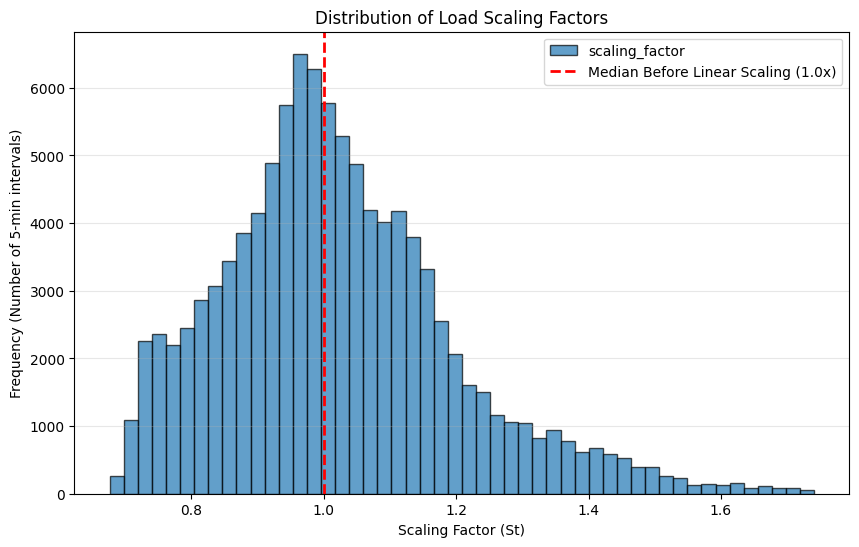

In [184]:
import matplotlib.pyplot as plt

### Plot scaling factors as this is
data = df['scaling_factor']
plt.figure(figsize=(10, 6))

# Plot the histogram with 50 bins for a clean resolution
df['scaling_factor'].plot.hist(
    bins=50, 
    color='#1f77b4',      # Standard blue
    edgecolor='black',    # Adds borders to the bars so they don't blur together
    alpha=0.7             # Slight transparency
)

# Add a red dashed line exactly at the mean (1.0)
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Median Before Linear Scaling (1.0x)')

# Format the chart
plt.title('Distribution of Load Scaling Factors')
plt.xlabel('Scaling Factor (St)')
plt.ylabel('Frequency (Number of 5-min intervals)')
plt.grid(True, alpha=0.3, axis='y') # Only grid the y-axis for cleaner look
plt.legend()

plt.show()

# <span style = "color:green"> Define Our Two Stage Optimization Problem </span>

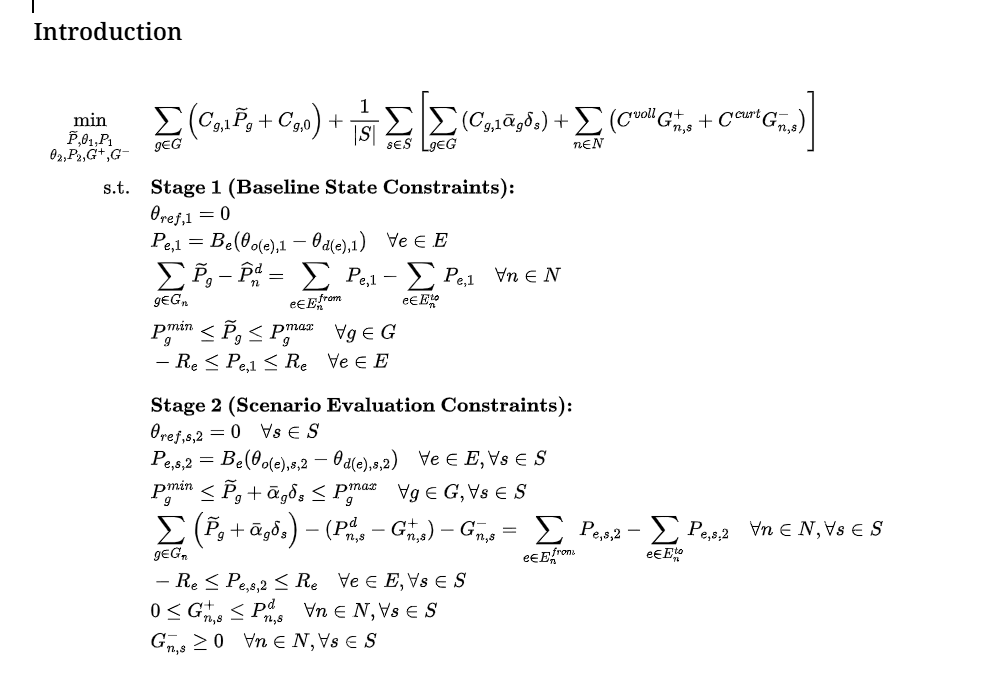

In [185]:
# =============================================================================
# Two-Stage Stochastic DC-OPF — RHS UPDATED FAST CLASS
# =============================================================================
import numpy as np
import scipy.sparse as sp
import gurobipy as gp
from gurobipy import GRB

# Asymmetric ramp cost multiplier: upward ramps (underprediction) are penalised
# UNDER_MULT times more than downward ramps (overprediction).
UNDER_MULT = 5.0

# ----- Sparse incidence matrices (built once, reused per solve) -----
# Generator-to-bus map: G_bus[n, g] = 1 iff generator g sits on bus n.
_G_bus_sp = sp.csr_matrix(
    (np.ones(N_GEN), (gen_bus_idx, np.arange(N_GEN))),
    shape=(N_BUS, N_GEN),
)
# Line incidence: A_inc[e, n] = +1 if line e leaves bus n, -1 if it enters.
_A_inc_sp = sp.csr_matrix(
    (
        np.concatenate([np.ones(N_LINE), -np.ones(N_LINE)]),
        (
            np.concatenate([np.arange(N_LINE), np.arange(N_LINE)]),
            np.concatenate([from_idx, to_idx]),
        ),
    ),
    shape=(N_LINE, N_BUS),
)
# Susceptance-weighted incidence so DC flow is just B_inc @ theta.
_B_inc_sp = sp.diags(B_line) @ _A_inc_sp

class FastStochasticOPF:
    """
    Persistent Gurobi model. Builds the massive Stage 1 and Stage 2 matrix exactly
    once. Allows instantaneous updates to demand parameters via .RHS and .UB.
    """
    def __init__(self, N_SCEN, voll=VOLL, c_curt=C_CURT, weights=None, verbose=False, return_lmps=False):
        self.N_SCEN = N_SCEN
        self.return_lmps = return_lmps
        
        if weights is None:
            weights = np.full(N_SCEN, 1.0 / N_SCEN)
        self.weights = np.asarray(weights, dtype=float)

        m = gp.Model("stochastic_dcopf_piecewise_4tier_fast")
        m.Params.OutputFlag = 1 if verbose else 0
        m.Params.Threads   = 0
        m.Params.Presolve  = 2
        
        # --- NEW LOGIC: Smart Method Selection ---
        if N_SCEN == 1:
            # Grid Search (Tiny Matrix): Use Dual Simplex
            m.Params.Method = 1
        else:
            # Full Evaluation (Massive Matrix): Use Barrier without Crossover
            m.Params.Method = 2
            m.Params.Crossover = -1 if return_lmps else 0

        # --- Stage 1 variables ---
        self.Pg    = m.addMVar(N_GEN,  lb=Pg_min, ub=Pg_max,    name="Pg")
        theta1     = m.addMVar(N_BUS,  lb=-GRB.INFINITY,        name="theta1")
        Pe1        = m.addMVar(N_LINE, lb=-R_line, ub=R_line,   name="Pe1")
        self.shed1 = m.addMVar(N_BUS,  lb=0.0,                  name="shed1")
        self.curt1 = m.addMVar(N_BUS,  lb=0.0,                  name="curt1")

        # --- Stage 2 variables (UB for G_shed set dynamically later) ---
        self.G_shed = m.addMVar((N_SCEN, N_BUS), lb=0.0, ub=GRB.INFINITY, name="G_shed") 
        self.G_curt = m.addMVar((N_SCEN, N_BUS), lb=0.0,                  name="G_curt")
        theta2      = m.addMVar((N_SCEN, N_BUS), lb=-GRB.INFINITY,        name="theta2")
        Pe2         = m.addMVar((N_SCEN, N_LINE),
                                lb=np.tile(-R_line, (N_SCEN, 1)),
                                ub=np.tile( R_line, (N_SCEN, 1)),
                                name="Pe2")

        # 4-tier ramp block limits
        b1, b2, b3, b4 = 0.03 * Pg_max, 0.07 * Pg_max, 0.10 * Pg_max, 0.80 * Pg_max
        ub_b1, ub_b2, ub_b3, ub_b4 = np.tile(b1, (N_SCEN, 1)), np.tile(b2, (N_SCEN, 1)), np.tile(b3, (N_SCEN, 1)), np.tile(b4, (N_SCEN, 1))

        r_up_1 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b1, name="r_up_1")
        r_up_2 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b2, name="r_up_2")
        r_up_3 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b3, name="r_up_3")
        r_up_4 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b4, name="r_up_4")
        r_dn_1 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b1, name="r_dn_1")
        r_dn_2 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b2, name="r_dn_2")
        r_dn_3 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b3, name="r_dn_3")
        r_dn_4 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b4, name="r_dn_4")

        sum_up = r_up_1 + r_up_2 + r_up_3 + r_up_4
        sum_dn = r_dn_1 + r_dn_2 + r_dn_3 + r_dn_4

        # --- Stage 1 constraints ---
        m.addConstr(theta1[SLACK] == 0, name="slack1")
        m.addConstr(Pe1 == _B_inc_sp @ theta1, name="dc_flow_1")
        
        # Save pointer to balance constraint so we can update its RHS
        self.bal1 = m.addConstr(
            _G_bus_sp @ self.Pg + self.shed1 - self.curt1 - _A_inc_sp.T @ Pe1 == np.zeros(N_BUS),
            name="balance1",
        )

        # --- Stage 2 constraints ---
        self.bal2_constrs = []
        for s in range(N_SCEN):
            m.addConstr(theta2[s, SLACK] == 0, name=f"slack2_{s}")
            m.addConstr(Pe2[s, :] == _B_inc_sp @ theta2[s, :], name=f"dc_flow_2_{s}")

            Pg_rt_s = self.Pg + sum_up[s, :] - sum_dn[s, :]
            m.addConstr(Pg_rt_s >= Pg_min, name=f"pg_lo_{s}")
            m.addConstr(Pg_rt_s <= Pg_max, name=f"pg_hi_{s}")

            # Algebraically identical: variables on LHS, constants (Demand) on RHS
            bal2_s = m.addConstr(
                _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),
                name=f"balance2_{s}",
            )
            self.bal2_constrs.append(bal2_s)

        # --- Objective ---
        safe_Pg_max = np.where(Pg_max == 0, 1.0, Pg_max)
        inv_pgmax   = 1.0 / safe_Pg_max 

        stage1_gen_cost   = c1 @ self.Pg + float(np.sum(c0))
        stage1_slack_cost = (10 * voll) * self.shed1.sum() + (10 * c_curt) * self.curt1.sum()
        stage1_cost       = stage1_gen_cost + stage1_slack_cost

        W = self.weights[:, None] 
        total_stage2_gen = (W * c1[None, :] * (sum_up - sum_dn)).sum()

        # Asymmetric ramp costs: upward ramps (underprediction) cost UNDER_MULT x more.
        total_ramp = (
            (W * (UNDER_MULT * 1e3 * inv_pgmax[None, :]) * r_up_1 + W * (1e3 * inv_pgmax[None, :]) * r_dn_1).sum()
          + (W * (UNDER_MULT * 2e3 * inv_pgmax[None, :]) * r_up_2 + W * (2e3 * inv_pgmax[None, :]) * r_dn_2).sum()
          + (W * (UNDER_MULT * 1e4 * inv_pgmax[None, :]) * r_up_3 + W * (1e4 * inv_pgmax[None, :]) * r_dn_3).sum()
          + (W * (UNDER_MULT * 1e7 * inv_pgmax[None, :]) * r_up_4 + W * (1e7 * inv_pgmax[None, :]) * r_dn_4).sum()
        )
        total_shed_2 = voll   * (W * self.G_shed).sum()
        total_curt_2 = c_curt * (W * self.G_curt).sum()

        expected_stage2 = total_stage2_gen + total_ramp + total_shed_2 + total_curt_2
        m.setObjective(stage1_cost + expected_stage2, GRB.MINIMIZE)

        self.m = m

    def solve(self, Pd_hat, node_scen):
        """ Instantly updates the matrix memory and runs the barrier method. """
        # 1. Update Stage 1 Right-Hand Side
        self.bal1.RHS = Pd_hat
        
        # 2. Update Stage 2 Shed Bounds
        self.G_shed.UB = node_scen
        
        # 3. Update Stage 2 Right-Hand Side
        for s in range(self.N_SCEN):
            self.bal2_constrs[s].RHS = node_scen[s, :]

        # Gurobi executes immediately without rebuilding
        self.m.optimize()
        if self.m.Status != GRB.OPTIMAL:
            raise RuntimeError(f"Gurobi Status={self.m.Status}")

        LMP_1 = np.asarray(self.bal1.Pi) if self.return_lmps else None

        return {
            "Pg":          self.Pg.X,
            "shed1":       self.shed1.X,
            "curt1":       self.curt1.X,
            "shed":        self.G_shed.X,
            "curt":        self.G_curt.X,
            "total_cost":  self.m.ObjVal,
            "stage1_cost": float(c1 @ self.Pg.X + np.sum(c0)),
            "LMP_1":       LMP_1,
        }

# Wrapper for backward compatibility 
def optimization_model(Pd_hat, node_scen, voll=VOLL, c_curt=C_CURT,
                       verbose=True, return_lmps=False, weights=None):
    solver = FastStochasticOPF(node_scen.shape[0], voll, c_curt, weights, verbose, return_lmps)
    return solver.solve(Pd_hat, node_scen)


In [186]:

# =============================================================================
# AC Stage-2 Recourse Solver (IPOPT via Pyomo)
#
# Purpose: Given a fixed DC-committed dispatch Pg_star (from stage-1),
# evaluate the TRUE realized cost under full AC power flow physics.
#
# What this solves:
#   - Fix Pg as a warm-start around Pg_star (allow small re-dispatch)
#   - Find voltages (V, theta) satisfying full AC power flow equations
#   - Minimize real re-dispatch cost + load shedding under AC constraints
#   - Returns the AC realized cost including I^2*R losses
#
# The DC-to-AC gap = AC_realized_cost - DC_realized_cost quantifies how
# much the DC relaxation underestimates true operational costs.
# =============================================================================
import pyomo.environ as pyo
from pyomo.opt import SolverFactory as _SF
import numpy as np

# Build the Y-bus matrix (admittance) for AC power flow
# Y[i,j] = sum of series admittances of lines between i and j (off-diagonal, negated)
# Y[i,i] = sum of incident series admittances + shunt susceptances
def _build_ybus(N_BUS, from_idx, to_idx, g_series, b_series, b_shunt):
    """Returns G_bus (real) and B_bus (imag) as dense NxN arrays."""
    G = np.zeros((N_BUS, N_BUS))
    B = np.zeros((N_BUS, N_BUS))
    for l in range(len(from_idx)):
        i, j = from_idx[l], to_idx[l]
        g, b, bc = g_series[l], b_series[l], b_shunt[l]
        # Diagonal
        G[i, i] += g;      G[j, j] += g
        B[i, i] += -b + bc; B[j, j] += -b + bc   # b_series is negative, -b > 0
        # Off-diagonal
        G[i, j] -= g;      G[j, i] -= g
        B[i, j] += b;      B[j, i] += b
    return G, B

_G_ac, _B_ac = _build_ybus(N_BUS, from_idx, to_idx, g_series, b_series, b_shunt)

# Per-unit base (the .m file is already in MW/MVAr/kV — treat as p.u. scaled)
# For this 118-bus system all data is already in consistent MW units.
# We solve the AC-OPF in the same MW/MVAr units (no per-unit conversion needed
# since voltage bounds and Q limits are already in natural units from MATPOWER).

class ACRealizedStage2:
    """
    Solve an AC recourse problem given a fixed DC commitment Pg_star.

    The problem:
        min  c1^T * delta_P + VOLL * shed + C_CURT * curt
        s.t. AC power flow: P_inj = G*V^2 terms  (nonlinear)
             Pg = Pg_star + delta_P   (re-dispatch around commitment)
             Pg_min <= Pg <= Pg_max
             Qg_min <= Qg <= Qg_max
             Vmin <= V <= Vmax
             |S_line| <= S_rate  (apparent power limit)

    Uses IPOPT as the NLP solver. Falls back to DC cost if IPOPT is unavailable.
    """
    def __init__(self, voll=VOLL, c_curt=C_CURT, tol=1e-4):
        self.voll   = voll
        self.c_curt = c_curt
        self.tol    = tol
        # Check IPOPT availability once
        self._solver = _SF('ipopt')
        self._ipopt_available = self._solver.available()
        if not self._ipopt_available:
            print("WARNING: IPOPT not found. AC stage-2 will return DC approximation.")

    def solve(self, Pg_star, Pd_actual):
        """
        Parameters
        ----------
        Pg_star   : ndarray (N_GEN,)  DC-committed dispatch (MW)
        Pd_actual : ndarray (N_BUS,)  Realized nodal active demand (MW)

        Returns
        -------
        dict with keys: stage2_cost, shed, curt, ac_losses, v_min, v_max
        """
        if not self._ipopt_available:
            # Graceful fallback: use DC approximation (same as FastRealizedStage2)
            return {"stage2_cost": float(c1 @ Pg_star), "shed": 0.0,
                    "curt": 0.0, "ac_losses": 0.0, "v_min": 1.0, "v_max": 1.0,
                    "ac_feasible": False}

        m = pyo.ConcreteModel()

        buses = range(N_BUS)
        gens  = range(N_GEN)
        lines = range(N_LINE)

        # --- Variables ---
        m.V     = pyo.Var(buses, bounds=lambda m, i: (Vmin[i], Vmax[i]),
                          initialize=1.0)
        m.theta = pyo.Var(buses, initialize=0.0)
        m.Pg    = pyo.Var(gens,  bounds=lambda m, g: (Pg_min[g], Pg_max[g]),
                          initialize=lambda m, g: float(Pg_star[g]))
        m.Qg    = pyo.Var(gens,  bounds=lambda m, g: (Qg_min[g], Qg_max[g]),
                          initialize=0.0)
        m.shed  = pyo.Var(buses, bounds=lambda m, i: (0.0, float(Pd_actual[i])),
                          initialize=0.0)
        m.curt  = pyo.Var(buses, bounds=(0.0, None), initialize=0.0)

        # --- Slack bus ---
        m.slack_theta = pyo.Constraint(expr=m.theta[SLACK] == 0.0)
        m.slack_v     = pyo.Constraint(expr=m.V[SLACK] == 1.0)

        # --- AC Power flow: nodal P balance ---
        def _p_inj(i):
            return sum(
                m.V[i] * m.V[j] * (
                    _G_ac[i, j] * pyo.cos(m.theta[i] - m.theta[j]) +
                    _B_ac[i, j] * pyo.sin(m.theta[i] - m.theta[j])
                )
                for j in buses if _G_ac[i, j] != 0 or _B_ac[i, j] != 0
            )

        def _q_inj(i):
            return sum(
                m.V[i] * m.V[j] * (
                    _G_ac[i, j] * pyo.sin(m.theta[i] - m.theta[j]) -
                    _B_ac[i, j] * pyo.cos(m.theta[i] - m.theta[j])
                )
                for j in buses if _G_ac[i, j] != 0 or _B_ac[i, j] != 0
            )

        # Generator injection at each bus (sum over generators at that bus)
        _gen_at_bus_P = {i: [] for i in buses}
        _gen_at_bus_Q = {i: [] for i in buses}
        for g in gens:
            _gen_at_bus_P[gen_bus_idx[g]].append(g)
            _gen_at_bus_Q[gen_bus_idx[g]].append(g)

        def p_balance_rule(m, i):
            Pg_bus = sum(m.Pg[g] for g in _gen_at_bus_P[i])
            return Pg_bus + m.shed[i] - m.curt[i] - Pd_actual[i] == _p_inj(i)

        def q_balance_rule(m, i):
            Qg_bus = sum(m.Qg[g] for g in _gen_at_bus_Q[i])
            return Qg_bus - Qd_bus[i] == _q_inj(i)

        m.p_balance = pyo.Constraint(buses, rule=p_balance_rule)
        m.q_balance = pyo.Constraint(buses, rule=q_balance_rule)

        # --- Apparent power line limits (relaxed to avoid infeasibility) ---
        # S^2 = P^2 + Q^2 <= S_rate^2
        def s_limit_rule(m, l):
            i, j = int(from_idx[l]), int(to_idx[l])
            g, b = g_series[l], b_series[l]
            # From-end MW and MVAr
            Pij = m.V[i]**2 * g - m.V[i]*m.V[j]*(g*pyo.cos(m.theta[i]-m.theta[j]) + b*pyo.sin(m.theta[i]-m.theta[j]))
            Qij = -m.V[i]**2 * b - m.V[i]*m.V[j]*(g*pyo.sin(m.theta[i]-m.theta[j]) - b*pyo.cos(m.theta[i]-m.theta[j]))
            return Pij**2 + Qij**2 <= S_rate[l]**2
        m.s_limit = pyo.Constraint(lines, rule=s_limit_rule)

        # --- Objective ---
        # Penalise re-dispatch from Pg_star (c1 cost of net change) + shedding/curtailment
        re_dispatch_cost = sum(c1[g] * m.Pg[g] for g in gens)
        shed_cost        = self.voll   * sum(m.shed[i] for i in buses)
        curt_cost        = self.c_curt * sum(m.curt[i] for i in buses)
        m.obj = pyo.Objective(expr=re_dispatch_cost + shed_cost + curt_cost,
                              sense=pyo.minimize)

        # Warm-start: fix Pg near Pg_star to help IPOPT converge
        for g in gens:
            m.Pg[g].set_value(float(np.clip(Pg_star[g], Pg_min[g], Pg_max[g])))

        self._solver.options['tol']             = self.tol
        self._solver.options['max_iter']        = 300
        self._solver.options['print_level']     = 0
        self._solver.options['warm_start_init_point'] = 'yes'

        result = self._solver.solve(m, tee=False)

        ok = result.solver.termination_condition in [
            pyo.TerminationCondition.optimal,
            pyo.TerminationCondition.locallyOptimal,
            pyo.TerminationCondition.feasible,
        ]

        if not ok:
            # IPOPT failed — fall back to DC recourse cost as conservative estimate
            return {"stage2_cost": float(c1 @ Pg_star), "shed": 0.0,
                    "curt": 0.0, "ac_losses": 0.0, "v_min": 1.0, "v_max": 1.0,
                    "ac_feasible": False}

        Pg_ac = np.array([pyo.value(m.Pg[g]) for g in gens])
        V_ac  = np.array([pyo.value(m.V[i])  for i in buses])

        # AC losses = total generation - total demand (after shedding)
        shed_total = sum(pyo.value(m.shed[i]) for i in buses)
        ac_losses  = Pg_ac.sum() - (Pd_actual.sum() - shed_total)

        return {
            "stage2_cost": float(pyo.value(m.obj)),
            "shed":        float(shed_total),
            "curt":        float(sum(pyo.value(m.curt[i]) for i in buses)),
            "ac_losses":   float(ac_losses),
            "v_min":       float(V_ac.min()),
            "v_max":       float(V_ac.max()),
            "ac_feasible": True,
        }


# Instantiate the AC solver once (checks IPOPT availability)
_ac_stage2_solver = ACRealizedStage2(voll=VOLL, c_curt=C_CURT)
print(f"AC stage-2 solver ready. IPOPT available: {_ac_stage2_solver._ipopt_available}")
print(f"Y-bus built: G range [{_G_ac.min():.4f}, {_G_ac.max():.4f}], "
      f"B range [{_B_ac.min():.4f}, {_B_ac.max():.4f}]")


AC stage-2 solver ready. IPOPT available: True
Y-bus built: G range [-27.8439, 56.1958], B range [-245.1856, 384.1923]


# <span style="color:green">Method 1: Predict Demand and Generate Scenarios from LogNormal Distribution</span>

##  Decide between lognormal and gamma distributions for scaling factor data

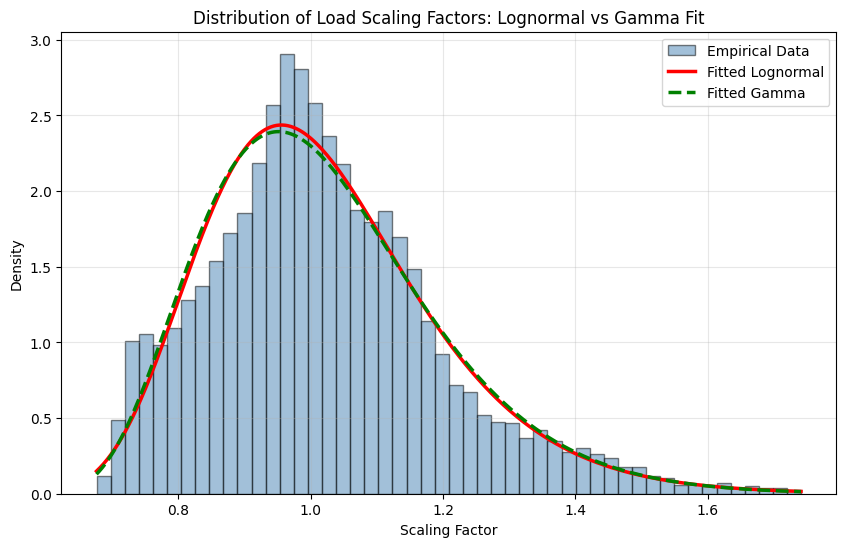

In [187]:
### Fit a distribution to the scaling factors
import scipy.stats as stats

# Assuming 'df' is your DataFrame and 'scaling_factor' is the column
# Drop any NaN values before fitting
data = df['scaling_factor'].dropna().values

shape_lognorm, loc_lognorm, scale_lognorm = stats.lognorm.fit(data)
shape_gamma, loc_gamma, scale_gamma = stats.gamma.fit(data)

x = np.linspace(data.min(), data.max(), 1000)
pdf_lognorm = stats.lognorm.pdf(x, shape_lognorm, loc_lognorm, scale_lognorm)
pdf_gamma = stats.gamma.pdf(x, shape_gamma, loc_gamma, scale_gamma)

# --- 4. Plot the Results ---
plt.figure(figsize=(10, 6))

# Plot the empirical histogram (must set density=True to match PDF scale)
plt.hist(data, bins=50, density=True, alpha=0.5, color='steelblue', edgecolor='black', label='Empirical Data')

# Overlay the fitted PDFs
plt.plot(x, pdf_lognorm, 'r-', lw=2.5, label='Fitted Lognormal')
plt.plot(x, pdf_gamma, 'g--', lw=2.5, label='Fitted Gamma')

plt.title('Distribution of Load Scaling Factors: Lognormal vs Gamma Fit')
plt.xlabel('Scaling Factor')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [188]:
# Calculate the negative log-likelihood (NLL) for both fits
# NLL is what scipy actually minimizes during the fit
nll_lognorm = stats.lognorm.nnlf((shape_lognorm, loc_lognorm, scale_lognorm), data)
nll_gamma = stats.gamma.nnlf((shape_gamma, loc_gamma, scale_gamma), data)

# Number of parameters (k) is 3 for both distributions (shape, loc, scale)
k = 3
n = len(data)

# Calculate AIC: AIC = 2k - 2*ln(L)  (where -ln(L) is the NLL)
aic_lognorm = 2 * k + 2 * nll_lognorm
aic_gamma = 2 * k + 2 * nll_gamma

print(f"Lognormal AIC: {aic_lognorm:.2f}")
print(f"Gamma AIC: {aic_gamma:.2f}")

if aic_lognorm < aic_gamma:
    print("The Lognormal distribution provides a better fit.")
else:
    print("The Gamma distribution provides a better fit.")

Lognormal AIC: -74909.01
Gamma AIC: -75137.59
The Gamma distribution provides a better fit.


In [189]:
### Generate the scenarios
num_samples = 100
scale_scenarios = stats.lognorm.rvs(shape_lognorm, loc=loc_lognorm, scale=scale_lognorm, size=num_samples)
nodes_to_mult = nodal_demand['Pd_mw']
node_scenarios = np.outer(scale_scenarios, nodes_to_mult)

In [190]:
from scipy.stats import lognorm
scaling_factor_hat = lognorm.mean(shape_lognorm, loc=loc_lognorm, scale=scale_lognorm)
Pn_d_hat = scaling_factor_hat * nodal_demand.set_index('bus_id')['Pd_mw']

In [191]:
# Align Pn_d_hat to bus order
if isinstance(Pn_d_hat, pd.Series):
    Pd_hat = np.array([Pn_d_hat[b] for b in bus_ids])
else:
    Pd_hat = np.asarray(Pn_d_hat)


node_scen = np.asarray(node_scenarios)
N_SCEN    = node_scen.shape[0]


## <span style = "color:green"> Run Two Stage Optimization Evaluation </span>

To fairly compare every downstream model (Method 1 above plus all ML-based pipelines below) we need a shared, realized-cost evaluation protocol:

1. **Train/test split (temporal).** First 4 years (2019–2022) form the training set; the final year (2023) is the held-out test set. This clean temporal boundary prevents any look-ahead leakage while giving the models full seasonal diversity in training.
2. **Realized stage-2 cost.** Given a stage-1 decision `(Pg*, α*)` solved under forecast `Pd_hat`, the actual demand `Pd_actual(t)` is revealed in the next 5-min window. The realized recourse cost comes from a *single-scenario* stage-2 LP with `Pg_applied = Pg* + α*·(Σ Pd_actual − Σ Pd_hat)` held fixed — optimizing only `θ, Pe, shed, curt, gen-limit-slack`.
3. **Evaluation loop.** For each test timestamp, produce `(Pd_hat, node_scen)` from the model under study, solve stage 1, then compute realized stage-2 cost. Total realized cost = stage-1 cost + realized stage-2 cost. Collect over N_TEST timestamps, report mean/std/CI.
4. **Shared test set.** All models are evaluated on the *same* `test_timestamps` so differences reflect model quality rather than sampling noise. This also enables paired comparisons later.

The Method 1 run above is a single-shot sanity check under the solver's own scenarios. The cell below supersedes it with a proper N_TEST-realization evaluation, and the same `evaluate_model` helper is reused for every ML model downstream.


In [192]:
## This Evaluation Code Can Be Shared Across All Models

import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import scipy.stats as stats

# -----------------------------------------------------------------------------
# 1. Train / test split (temporal: first N-1 years train, last year test)
#
# TRAIN_END is derived automatically from the data so the split works whether
# we have 1 year (2019 only) or the full 5-year dataset (2019-2023).
# When only one year is available, the last 2 months are held out as test.
# -----------------------------------------------------------------------------
N_TEST     = 1000   # number of test timestamps used to evaluate each model
SPLIT_SEED = 42

rng_split = np.random.default_rng(SPLIT_SEED)

_last_year = df.index.year.max()
_first_year = df.index.year.min()
TRAIN_END  = pd.Timestamp(f"{_last_year}-01-01")
train_df   = df.loc[df.index < TRAIN_END].copy()
test_df    = df.loc[df.index >= TRAIN_END].copy()

# If there is only one year of data, fall back to 10-month train / 2-month test.
if len(train_df) == 0:
    TRAIN_END = pd.Timestamp(f"{_first_year}-11-01")   # Nov 1 → last 2 months test
    train_df  = df.loc[df.index < TRAIN_END].copy()
    test_df   = df.loc[df.index >= TRAIN_END].copy()
    print(f"[!] Only one year of data — using 10-month train / 2-month test split "
          f"(train ends {TRAIN_END.date()}).")

_n_test = min(N_TEST, len(test_df))
if _n_test < N_TEST:
    print(f"[!] Test pool has only {len(test_df):,} rows; reducing N_TEST to {_n_test}.")

# Draw test timestamps from the test pool once and reuse across every model.
_test_idx       = rng_split.choice(len(test_df), size=_n_test, replace=False)
test_timestamps = test_df.index[np.sort(_test_idx)]
test_dates      = pd.to_datetime(test_timestamps.normalize().unique())   # kept for compat

print(f"Train rows: {len(train_df):,}  |  Test rows: {len(test_df):,}  |  "
      f"Train up to: {train_df.index.max().date()}  |  "
      f"Test from: {test_df.index.min().date()}  |  N_TEST: {len(test_timestamps)}")


[!] Only one year of data — using 10-month train / 2-month test split (train ends 2019-11-01).
Train rows: 87,540  |  Test rows: 17,508  |  Train up to: 2019-10-31  |  Test from: 2019-11-01  |  N_TEST: 1000


In [193]:
# =============================================================================
# Shared evaluation infrastructure: FastRealizedStage2, evaluate_model,
# summarize_results — used by every model cell downstream.
# =============================================================================
from tqdm import tqdm

# -----------------------------------------------------------------------------
# Realized nodal demand helper
# -----------------------------------------------------------------------------
# Align scaled_nodal_demand columns to bus_ids order once.
_nodal_by_bus = scaled_nodal_demand.reindex(columns=bus_ids)
assert not np.isnan(_nodal_by_bus.values).any(), "NaN in _nodal_by_bus"

def pd_actual_at(ts):
    """Return the realized nodal demand vector (MW) at timestamp ts, aligned to bus_ids."""
    return _nodal_by_bus.loc[ts].values.astype(float)

# -----------------------------------------------------------------------------
# Realized stage-2 cost (single scenario, Pg fixed) — FAST GUROBI CLASS
# -----------------------------------------------------------------------------
class FastRealizedStage2:
    def __init__(self, voll=VOLL, c_curt=C_CURT):
        m = gp.Model("stage2_realized_fast")
        m.Params.OutputFlag = 0
        m.Params.Method  = 1  # Dual simplex
        m.Params.Threads = 1

        b1_limit = 0.03 * Pg_max
        b2_limit = 0.07 * Pg_max
        b3_limit = 0.10 * Pg_max
        b4_limit = 0.80 * Pg_max

        self.r_up_1 = m.addMVar(N_GEN, lb=0.0, ub=b1_limit, name="r_up_1")
        self.r_up_2 = m.addMVar(N_GEN, lb=0.0, ub=b2_limit, name="r_up_2")
        self.r_up_3 = m.addMVar(N_GEN, lb=0.0, ub=b3_limit, name="r_up_3")
        self.r_up_4 = m.addMVar(N_GEN, lb=0.0, ub=b4_limit, name="r_up_4")
        self.r_dn_1 = m.addMVar(N_GEN, lb=0.0, ub=b1_limit, name="r_dn_1")
        self.r_dn_2 = m.addMVar(N_GEN, lb=0.0, ub=b2_limit, name="r_dn_2")
        self.r_dn_3 = m.addMVar(N_GEN, lb=0.0, ub=b3_limit, name="r_dn_3")
        self.r_dn_4 = m.addMVar(N_GEN, lb=0.0, ub=b4_limit, name="r_dn_4")

        self.G_shed = m.addMVar(N_BUS, lb=0.0, ub=GRB.INFINITY, name="G_shed")
        self.G_curt = m.addMVar(N_BUS, lb=0.0,                  name="G_curt")
        theta       = m.addMVar(N_BUS, lb=-GRB.INFINITY,        name="theta")
        Pe          = m.addMVar(N_LINE, lb=-R_line, ub=R_line,  name="Pe")

        sum_up = self.r_up_1 + self.r_up_2 + self.r_up_3 + self.r_up_4
        sum_dn = self.r_dn_1 + self.r_dn_2 + self.r_dn_3 + self.r_dn_4
        sum_net_ramp = sum_up - sum_dn

        m.addConstr(theta[SLACK] == 0)
        m.addConstr(Pe == _B_inc_sp @ theta)

        self.pg_min_constr = m.addConstr(sum_net_ramp >= np.zeros(N_GEN))
        self.pg_max_constr = m.addConstr(sum_net_ramp <= np.zeros(N_GEN))

        self.bal_constr = m.addConstr(
            _G_bus_sp @ sum_net_ramp + self.G_shed - self.G_curt - _A_inc_sp.T @ Pe == np.zeros(N_BUS)
        )

        safe_Pg_max = np.where(Pg_max == 0, 1.0, Pg_max)
        inv_pgmax   = 1.0 / safe_Pg_max

        # Asymmetric ramp costs: upward ramps (underprediction) cost UNDER_MULT x more.
        ramp_cost = (
            (UNDER_MULT * 1e3 * inv_pgmax) @ self.r_up_1 + (1e3 * inv_pgmax) @ self.r_dn_1
          + (UNDER_MULT * 2e3 * inv_pgmax) @ self.r_up_2 + (2e3 * inv_pgmax) @ self.r_dn_2
          + (UNDER_MULT * 1e4 * inv_pgmax) @ self.r_up_3 + (1e4 * inv_pgmax) @ self.r_dn_3
          + (UNDER_MULT * 1e7 * inv_pgmax) @ self.r_up_4 + (1e7 * inv_pgmax) @ self.r_dn_4
        )
        stage2_gen_cost = c1 @ sum_net_ramp
        shed_cost = voll   * self.G_shed.sum()
        curt_cost = c_curt * self.G_curt.sum()

        m.setObjective(stage2_gen_cost + ramp_cost + shed_cost + curt_cost, GRB.MINIMIZE)
        self.m = m

    def solve(self, Pg_star, Pd_actual):
        self.G_shed.UB = Pd_actual
        self.pg_min_constr.RHS = Pg_min - Pg_star
        self.pg_max_constr.RHS = Pg_max - Pg_star
        self.bal_constr.RHS    = Pd_actual - (_G_bus_sp @ Pg_star)
        self.m.optimize()

        if self.m.Status not in [GRB.OPTIMAL, GRB.SUBOPTIMAL]:
            raise RuntimeError(f"Realized stage-2 did not solve, status={self.m.Status}")

        total_ramp = float(
            self.r_up_1.X.sum() + self.r_up_2.X.sum() + self.r_up_3.X.sum() + self.r_up_4.X.sum()
          + self.r_dn_1.X.sum() + self.r_dn_2.X.sum() + self.r_dn_3.X.sum() + self.r_dn_4.X.sum()
        )
        return {
            "stage2_cost": float(self.m.ObjVal),
            "shed":        float(self.G_shed.X.sum()),
            "curt":        float(self.G_curt.X.sum()),
            "total_ramp":  total_ramp,
            "delta":       float(Pd_actual.sum() - Pg_star.sum()),
        }


# -----------------------------------------------------------------------------
# Evaluation loop
# -----------------------------------------------------------------------------
def evaluate_model(name, predict_fn, test_timestamps, verbose_every=20,
                   use_ac_stage2=False):
    rows  = []
    cache = {}
    fast_solver          = None
    current_weights_key  = None

    if use_ac_stage2:
        fast_stage2_solver = _ac_stage2_solver
    else:
        fast_stage2_solver = FastRealizedStage2(voll=VOLL, c_curt=C_CURT)

    for i, ts in tqdm(enumerate(test_timestamps), total=len(test_timestamps), desc=f"Eval {name}"):
        out = predict_fn(ts)
        if len(out) == 2:
            Pd_hat, node_scen = out
            weights = None
        else:
            Pd_hat, node_scen, weights = out

        wkey = None if weights is None else np.asarray(weights, dtype=float).tobytes()
        key  = (Pd_hat.tobytes(), node_scen.tobytes(), wkey)

        if key not in cache:
            if fast_solver is None or wkey != current_weights_key:
                fast_solver = FastStochasticOPF(
                    N_SCEN=node_scen.shape[0],
                    voll=VOLL,
                    c_curt=C_CURT,
                    weights=weights,
                    verbose=False
                )
                current_weights_key = wkey

            r = fast_solver.solve(Pd_hat, node_scen)
            cache[key] = r["Pg"].copy()

        Pg_star               = cache[key]
        deterministic_s1_cost = float(c1 @ Pg_star)
        Pd_actual             = pd_actual_at(ts)
        r2                    = fast_stage2_solver.solve(Pg_star, Pd_actual)

        row = {
            "model":                name,
            "ts":                   ts,
            "stage1_cost":          deterministic_s1_cost,
            "stage2_cost_realized": r2["stage2_cost"],
            "total_realized":       deterministic_s1_cost + r2["stage2_cost"],
            "shed_mw":              r2["shed"],
            "curt_mw":              r2["curt"],
            "total_ramp_mw":        r2.get("total_ramp", 0.0),
            "delta_mw":             r2.get("delta", float(Pd_actual.sum() - Pg_star.sum())),
        }
        if use_ac_stage2:
            row["ac_losses_mw"] = r2.get("ac_losses", 0.0)
            row["ac_feasible"]  = r2.get("ac_feasible", False)
            row["v_min"]        = r2.get("v_min", float("nan"))
            row["v_max"]        = r2.get("v_max", float("nan"))
        rows.append(row)

    return pd.DataFrame(rows)


# -----------------------------------------------------------------------------
# Summary helper
# -----------------------------------------------------------------------------
def summarize_results(results_df, alpha=0.05):
    from scipy.stats import t
    n     = len(results_df)
    mean  = results_df["total_realized"].mean()
    std   = results_df["total_realized"].std(ddof=1)
    tcrit = t.ppf(1 - alpha / 2, df=n - 1)
    half  = tcrit * std / np.sqrt(n)
    return pd.Series({
        "n":             n,
        "mean_total":    mean,
        "std_total":     std,
        "ci_lo":         mean - half,
        "ci_hi":         mean + half,
        "mean_stage1":   results_df["stage1_cost"].mean(),
        "mean_stage2":   results_df["stage2_cost_realized"].mean(),
        "mean_shed_mw":  results_df["shed_mw"].mean(),
        "mean_curt_mw":  results_df["curt_mw"].mean(),
        "mean_ramp_mw":  results_df["total_ramp_mw"].mean(),
        "frac_shed_gt1": (results_df["shed_mw"] > 1.0).mean(),
        "mean_ac_losses_mw":  results_df["ac_losses_mw"].mean()  if "ac_losses_mw" in results_df else float("nan"),
        "mean_v_min":         results_df["v_min"].mean()          if "v_min"        in results_df else float("nan"),
        "mean_v_max":         results_df["v_max"].mean()          if "v_max"        in results_df else float("nan"),
        "frac_ac_infeasible": (~results_df["ac_feasible"]).mean() if "ac_feasible"  in results_df else float("nan"),
    })


print("pd_actual_at, FastRealizedStage2, evaluate_model, summarize_results defined.")
print(f"Asymmetric ramp costs active: UNDER_MULT={UNDER_MULT} (up-ramp penalty multiplier).")


pd_actual_at, FastRealizedStage2, evaluate_model, summarize_results defined.
Asymmetric ramp costs active: UNDER_MULT=5.0 (up-ramp penalty multiplier).


## Evaluate Model 1

In [194]:

# -----------------------------------------------------------------------------
# 4. Method 1 evaluation — lognormal fit on TRAIN ONLY (overrides earlier globals)
# -----------------------------------------------------------------------------
_train_sf = train_df["scaling_factor"].dropna().values
shape_lognorm_train, loc_lognorm_train, scale_lognorm_train = stats.lognorm.fit(_train_sf)

# Point prediction: mean of train-fit lognormal, scaled onto per-bus base demand.
_scale_hat_m1 = stats.lognorm.mean(shape_lognorm_train,
                                   loc_lognorm_train,
                                   scale_lognorm_train)
_base_bus     = nodal_demand.set_index("bus_id").loc[bus_ids, "Pd_mw"].values.astype(float)
Pd_hat_m1     = _scale_hat_m1 * _base_bus

# 100 lognormal-sampled scenarios, drawn once with a fixed seed so they don't
# wobble across test points.
_SCEN_SEED = 123
_scale_scen = stats.lognorm.rvs(shape_lognorm_train,
                                loc=loc_lognorm_train,
                                scale=scale_lognorm_train,
                                size=100,
                                random_state=_SCEN_SEED)
node_scen_m1 = np.outer(_scale_scen, _base_bus)

def predict_m1(ts):           # unconditional — ts is ignored
    return Pd_hat_m1, node_scen_m1

print("\n>>> Evaluating Method 1 (lognormal mean + lognormal scenarios) over test set...")
results_m1 = evaluate_model("M1_lognormal", predict_m1, test_timestamps)

print("\nMethod 1 summary:")
print(summarize_results(results_m1).to_string())

# Store results registry for downstream aggregation.
all_model_results = {"M1_lognormal": results_m1}



>>> Evaluating Method 1 (lognormal mean + lognormal scenarios) over test set...


Eval M1_lognormal:   0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/nn/n3_8rlvx6h9bxwg2t6d_0xth0000gn/T/ipykernel_92660/4039276040.py:114: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),
Eval M1_lognormal: 100%|██████████| 1000/1000 [00:02<00:00, 372.49it/s]


Method 1 summary:
n                       1000.000000
mean_total            111822.829413
std_total              55455.317526
ci_lo                 108381.567117
ci_hi                 115264.091710
mean_stage1           108620.123574
mean_stage2             3202.705839
mean_shed_mw               0.000000
mean_curt_mw              17.059501
mean_ramp_mw             769.028933
frac_shed_gt1              0.000000
mean_ac_losses_mw               NaN
mean_v_min                      NaN
mean_v_max                      NaN
frac_ac_infeasible              NaN


# <span style = "color:red"> Machine Learning Based Pipelines

## <span style="color:green"> Model 2: Conditional Mean (GBR) + Lognormal Residual Scenarios</span>

Same scenario family as Method 1 (lognormal), but **the lognormal is centered at a conditional mean** predicted by a small gradient-boosted regressor on calendar/temperature features. Mathematically: `scaling_factor = μ(features) · ε`, with `ε ~ Lognormal` fit once on training residuals. Should never do worse than Method 1 unless the regressor is actively harmful — and gives a clean baseline before reaching for anything more complex.


In [195]:
# =============================================================================
# Method 1c: Zone-Aware Conditional Mean (per-zone GBR) + Copula Scenarios
#
# Pipeline:
#   1. Build per-zone scaling factors: zone_sf[t, z] = zone_load[t,z] / median_z
#   2. Fit 11 GBRs (one per zone) on TRAIN to predict zone_sf from features.
#   3. Fit 11 lognormals to per-zone multiplicative residuals.
#   4. Fit a Gaussian copula on the rank-transformed residuals to capture
#      cross-zone correlation (so heatwave-style co-spikes are preserved).
#   5. At test ts:
#        - μ_z = GBR_z(features_t)   for each zone z
#        - draw N_SCEN correlated residual vectors via copula
#        - bus_b's forecast = base_bus[b] · μ_{zone(b)}
#        - bus_b's scenario = base_bus[b] · μ_{zone(b)} · ε_{zone(b)}
# =============================================================================
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import lognorm, norm

# -----------------------------------------------------------------------------
# -1. Calendar feature engineering
#     Guard against re-adding if M1b already ran (idempotent).
# -----------------------------------------------------------------------------
if 'hour' not in df.columns:
    df['hour']         = df.index.hour
    df['day_of_week']  = df.index.dayofweek
    df['day_of_month'] = df.index.day
    df['week']         = df.index.isocalendar().week.values.astype(int)
    try:
        from pandas.tseries.holiday import USFederalHolidayCalendar
        _cal      = USFederalHolidayCalendar()
        _holidays = _cal.holidays(start=df.index.min(), end=df.index.max())
        df['is_holiday'] = df.index.normalize().isin(_holidays).astype(int)
    except Exception:
        df['is_holiday'] = 0
    print("[M1c] Calendar features added to df.")

if 'temperature_raw' not in df.columns:
    df['temperature_raw'] = df['temperature']

# System-level lag (24 h back at 5-min resolution = 288 steps).
# Used by Model 5's gbr; guard against double-adding.
if 'sf_lag_288' not in df.columns:
    df['sf_lag_288'] = df['scaling_factor'].shift(288)

# -----------------------------------------------------------------------------
# 0. Per-zone scaling factors (training target is now an 11-vector per timestep)
# -----------------------------------------------------------------------------
# zonal_df was built in the NYISO PERFORM cell. Each column is a zone's MW.
ZONE_NAMES = list(zonal_df.columns)              # 11 zone names, fixed order
N_ZONES    = len(ZONE_NAMES)

# Per-zone median (computed on TRAIN ONLY to avoid leakage)
_zonal_train = zonal_df.loc[zonal_df.index < TRAIN_END]
zone_median  = _zonal_train.median()             # Series indexed by zone name

# Per-zone scaling factor at every timestamp
zone_sf_full = zonal_df.div(zone_median, axis=1) # shape (T, 11)

# Align to df's index (df was built by inner-join with weather, so smaller)
zone_sf_full = zone_sf_full.reindex(df.index)

# -----------------------------------------------------------------------------
# 1. Bus -> zone map (already built by spectral clustering cell)
# -----------------------------------------------------------------------------
# bus_cluster[b_i] is the cluster id for bus i; cluster_to_zone[c] is the zone
# name for that cluster. Compose into a flat per-bus zone-index lookup.
zone_to_idx  = {z: i for i, z in enumerate(ZONE_NAMES)}
bus_zone_idx = np.array([zone_to_idx[cluster_to_zone[int(bus_cluster[i])]]
                         for i in range(N_BUS)], dtype=int)

# Static IEEE 118 nameplate per bus (same as M1b's _BASE_BUS)
_BASE_BUS = nodal_demand.set_index("bus_id").loc[bus_ids, "Pd_mw"].values.astype(float)

# -----------------------------------------------------------------------------
# 2. Per-zone lag features (each zone gets its OWN sf_lag_288)
# -----------------------------------------------------------------------------
# This replaces M1b's single system-level sf_lag_288 with 11 zone-specific lags,
# so each zonal GBR sees its own yesterday-same-slot demand.
for z in ZONE_NAMES:
    col = f"sf_lag_288_{z}"
    if col not in df.columns:
        df[col] = zone_sf_full[z].shift(288)

df = df.dropna()
train_df        = train_df.loc[train_df.index.intersection(df.index)]
test_df         = test_df.loc[test_df.index.intersection(df.index)]
test_timestamps = test_timestamps.intersection(df.index)
zone_sf_full    = zone_sf_full.reindex(df.index)

BASE_FEATS = ["temperature_raw", "hour", "day_of_week",
              "day_of_month", "week", "is_holiday"]

# Also keep FEATS in sync so Model 5 (which uses gbr + system-level sf_lag_288)
# still works when run after this cell.
FEATS = BASE_FEATS + ["sf_lag_288"]

def feats_for_zone(z):
    return BASE_FEATS + [f"sf_lag_288_{z}"]

# -----------------------------------------------------------------------------
# 3. Train 11 GBRs + 11 lognormals on TRAIN
# -----------------------------------------------------------------------------
zone_gbr        = {}                       # zone -> fitted GBR
zone_lognorm    = {}                       # zone -> (shape, loc, scale)
resid_train_mat = np.zeros((len(train_df), N_ZONES))   # for copula fit

print("[M1c] Training 11 per-zone GBRs...")
for zi, z in enumerate(ZONE_NAMES):
    feats_z = feats_for_zone(z)
    Xz_train = df.loc[train_df.index, feats_z].values
    yz_train = zone_sf_full.loc[train_df.index, z].values

    gbr_z = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                      learning_rate=0.05, random_state=0)
    gbr_z.fit(Xz_train, yz_train)
    zone_gbr[z] = gbr_z

    mu_tr_z      = gbr_z.predict(Xz_train)
    resid_mult_z = yz_train / mu_tr_z
    sh_z, lo_z, sc_z = lognorm.fit(resid_mult_z, floc=0)
    zone_lognorm[z] = (sh_z, lo_z, sc_z)

    resid_train_mat[:, zi] = resid_mult_z
    r2_z = gbr_z.score(Xz_train, yz_train)
    print(f"  {z:8s}  R^2={r2_z:.4f}  "
          f"lognorm shape={sh_z:.4f} scale={sc_z:.4f}")

# -----------------------------------------------------------------------------
# 4. Gaussian copula on residuals (preserves cross-zone correlation)
# -----------------------------------------------------------------------------
# Pipeline: residual -> empirical CDF (rank/n+1) -> normal quantile -> sample
# correlation matrix Sigma. To draw a correlated residual vector, sample
# z ~ N(0, Sigma), map to u = Phi(z), then to epsilon via the per-zone
# lognormal inverse CDF.
def _empirical_to_normal(x):
    """Rank-transform a 1-D array into standard normal scores."""
    n = len(x)
    ranks = pd.Series(x).rank(method="average").values
    u = ranks / (n + 1.0)                  # avoid 0/1 endpoints
    return norm.ppf(u)

resid_normal = np.column_stack([_empirical_to_normal(resid_train_mat[:, zi])
                                for zi in range(N_ZONES)])
Sigma = np.corrcoef(resid_normal, rowvar=False)        # 11 x 11

# Symmetrize + tiny ridge for numerical stability before Cholesky
Sigma = 0.5 * (Sigma + Sigma.T)
Sigma += 1e-6 * np.eye(N_ZONES)
L_chol = np.linalg.cholesky(Sigma)

print(f"[M1c] Cross-zone correlation (mean off-diag): "
      f"{(Sigma.sum() - np.trace(Sigma)) / (N_ZONES * (N_ZONES - 1)):.3f}")

# -----------------------------------------------------------------------------
# 5. Pre-draw N_SCEN correlated residual vectors ONCE (CRN across timestamps)
# -----------------------------------------------------------------------------
N_SCEN_M1C = 100
_m1c_rng   = np.random.default_rng(2024)

# Standard normals -> correlated normals -> uniforms -> per-zone lognormal eps
Z_iid       = _m1c_rng.standard_normal(size=(N_SCEN_M1C, N_ZONES))
Z_corr      = Z_iid @ L_chol.T                         # (N_SCEN, 11) correlated
U_corr      = norm.cdf(Z_corr)                         # uniforms in (0,1)

eps_zone = np.zeros_like(U_corr)                       # (N_SCEN, 11)
for zi, z in enumerate(ZONE_NAMES):
    sh_z, lo_z, sc_z = zone_lognorm[z]
    eps_zone[:, zi] = lognorm.ppf(U_corr[:, zi], sh_z, loc=lo_z, scale=sc_z)

# -----------------------------------------------------------------------------
# 6. Vectorized test-set predictions: μ_z(features_t) for every (t, z)
# -----------------------------------------------------------------------------
# Build an (N_TEST, 11) matrix of per-zone conditional means in one shot.
mu_test_mat = np.zeros((len(test_timestamps), N_ZONES))
for zi, z in enumerate(ZONE_NAMES):
    Xz_test = df.loc[test_timestamps, feats_for_zone(z)].values
    mu_test_mat[:, zi] = zone_gbr[z].predict(Xz_test)

mu_dict_m1c = {ts: mu_test_mat[i, :]
               for i, ts in enumerate(test_timestamps)}     # ts -> (11,)

# -----------------------------------------------------------------------------
# 7. predict_m1c: build Pd_hat and scenarios from per-zone μ + correlated eps
# -----------------------------------------------------------------------------
def predict_m1c(ts):
    mu_z = mu_dict_m1c[ts]                  # shape (11,)

    # Per-bus mean = nameplate × μ of that bus's zone
    mu_bus = mu_z[bus_zone_idx]             # shape (N_BUS,)
    Pd_hat = _BASE_BUS * mu_bus             # shape (N_BUS,)

    # Per-(scen, bus) scaling = μ_{zone(b)} × ε_{zone(b), s}
    # eps_zone has shape (N_SCEN, 11); broadcast to per-bus via bus_zone_idx.
    scen_zone_factor = mu_z[None, :] * eps_zone        # (N_SCEN, 11)
    scen_bus_factor  = scen_zone_factor[:, bus_zone_idx]  # (N_SCEN, N_BUS)
    scen             = _BASE_BUS[None, :] * scen_bus_factor

    return Pd_hat, scen

# -----------------------------------------------------------------------------
# 8. Evaluate
# -----------------------------------------------------------------------------
print("\n>>> Evaluating Method 1c (per-zone GBR + Gaussian copula) over test set...")
results_m1c = evaluate_model("M1c_zonal_gbr_copula", predict_m1c, test_timestamps)

print("\nMethod 1c summary:")
print(summarize_results(results_m1c).to_string())

all_model_results["M1c_zonal_gbr_copula"] = results_m1c


[M1c] Calendar features added to df.
[M1c] Training 11 per-zone GBRs...
  WEST      R^2=0.9307  lognorm shape=0.0358 scale=0.9991
  GENESE    R^2=0.9400  lognorm shape=0.0416 scale=0.9986
  CENTRL    R^2=0.9416  lognorm shape=0.0387 scale=0.9989
  NORTH     R^2=0.9072  lognorm shape=0.0405 scale=0.9990
  MHK VL    R^2=0.9488  lognorm shape=0.0438 scale=0.9986
  CAPTIL    R^2=0.9433  lognorm shape=0.0419 scale=0.9987
  HUD VL    R^2=0.9535  lognorm shape=0.0456 scale=0.9985
  MILLWD    R^2=0.9455  lognorm shape=0.0590 scale=0.9976
  DUNWOD    R^2=0.9650  lognorm shape=0.0406 scale=0.9988
  N.Y.C.    R^2=0.9816  lognorm shape=0.0272 scale=0.9994
  LONGIL    R^2=0.9734  lognorm shape=0.0435 scale=0.9986
[M1c] Cross-zone correlation (mean off-diag): 0.410

>>> Evaluating Method 1c (per-zone GBR + Gaussian copula) over test set...


Eval M1c_zonal_gbr_copula:   0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/nn/n3_8rlvx6h9bxwg2t6d_0xth0000gn/T/ipykernel_92660/4039276040.py:114: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),
Eval M1c_zonal_gbr_copula: 100%|██████████| 1000/1000 [04:32<00:00,  3.67it/s]


Method 1c summary:
n                      1000.000000
mean_total            79823.004584
std_total             10247.130161
ci_lo                 79187.122143
ci_hi                 80458.887025
mean_stage1           90334.105391
mean_stage2          -10511.100807
mean_shed_mw              0.000000
mean_curt_mw              0.001544
mean_ramp_mw            537.950659
frac_shed_gt1             0.000000
mean_ac_losses_mw              NaN
mean_v_min                     NaN
mean_v_max                     NaN
frac_ac_infeasible             NaN


## <span style = "color:green"> Model 5 </span>

In [197]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

# =============================================================================
# Model 5c: Zone-Aware Decision-Aware Meta-Learning
#
# Pipeline:
#   Phase 1: Coordinate-descent grid search over per-zone alphas.
#            - Initialize α_z = 1.0 for all zones.
#            - For each pass, sweep zones in order; for each zone, hold the
#              other 10 fixed and grid-search its α to minimize realized cost.
#            - Repeat for K_PASSES sweeps (typically converges in 2-3).
#            - Output: 11-vector α* per training timestamp.
#   Phase 2: Multi-output GBR meta-model: features -> 11 alphas.
#   Phase 3: Per-zone scaling of M1c's per-zone GBR forecast + copula scenarios.
#
# Requires: M1c artifacts (zone_gbr, zone_lognorm, eps_zone, mu_dict_m1c,
#           bus_zone_idx, ZONE_NAMES, N_ZONES) already in memory.
# =============================================================================

print("\n>>> Building Model 5c (Zone-Aware Decision-Aware GBR + Copula)...")

# --- PARAMETERS & FAST SOLVER SETUP ---
ALPHA_GRID  = np.linspace(0.75, 1.10, 25)
N_SCEN_M5C  = 80
K_PASSES    = 2          # coordinate-descent sweeps over zones
N_LABELS_M5C = 50        # training timestamps with α* labels

_m5c_rng = np.random.default_rng(2030)

# Re-draw 80 correlated copula residual vectors (smaller scenario count for speed
# during Phase 1 grid search).
Z_iid_m5c   = _m5c_rng.standard_normal(size=(N_SCEN_M5C, N_ZONES))
Z_corr_m5c  = Z_iid_m5c @ L_chol.T
U_corr_m5c  = norm.cdf(Z_corr_m5c)
eps_zone_m5c = np.zeros_like(U_corr_m5c)
for zi, z in enumerate(ZONE_NAMES):
    sh_z, lo_z, sc_z = zone_lognorm[z]
    eps_zone_m5c[:, zi] = lognorm.ppf(U_corr_m5c[:, zi], sh_z, loc=lo_z, scale=sc_z)

fast_grid_stage1_m5c = FastStochasticOPF(N_SCEN=N_SCEN_M5C, voll=VOLL,
                                         c_curt=C_CURT, verbose=False)
fast_grid_stage2_m5c = FastRealizedStage2(voll=VOLL, c_curt=C_CURT)


# -----------------------------------------------------------------------------
# Helper: build (Pd_hat, scen) for a given (mu_z, alpha_z) pair
# -----------------------------------------------------------------------------
def build_inputs_m5c(mu_z, alpha_z):
    """
    mu_z, alpha_z : shape (11,) — per-zone base means and per-zone alphas.
    Returns Pd_hat (N_BUS,) and scen (N_SCEN, N_BUS) consistent with M1c's
    bus -> zone broadcast structure, but with each zone scaled by alpha_z.
    """
    scaled_mu_z = alpha_z * mu_z                          # (11,)
    mu_bus      = scaled_mu_z[bus_zone_idx]               # (N_BUS,)
    Pd_hat      = _BASE_BUS * mu_bus

    # Scenario factor per (scen, zone) = scaled_mu_z * eps_zone
    scen_zone_factor = scaled_mu_z[None, :] * eps_zone_m5c   # (N_SCEN, 11)
    scen_bus_factor  = scen_zone_factor[:, bus_zone_idx]      # (N_SCEN, N_BUS)
    scen             = _BASE_BUS[None, :] * scen_bus_factor

    return Pd_hat, scen


def realized_cost_m5c(mu_z, alpha_z, Pd_actual):
    """One full two-stage solve at a given alpha vector. Returns total cost."""
    Pd_hat, scen = build_inputs_m5c(mu_z, alpha_z)
    r1 = fast_grid_stage1_m5c.solve(Pd_hat, scen)
    r2 = fast_grid_stage2_m5c.solve(r1["Pg"], Pd_actual)
    return r1["stage1_cost"] + r2["stage2_cost"]


# =============================================================================
# PHASE 0: Extend mu_dict_m1c to cover training timestamps needed by Phase 1
# =============================================================================
# mu_dict_m1c was built in M1c for test_timestamps only. Phase 1 needs
# per-zone means at training timestamps, so we compute and add them here.
alpha_train_timestamps_m5c = (train_df.sample(n=N_LABELS_M5C, random_state=42)
                                       .index.sort_values())

_missing = [ts for ts in alpha_train_timestamps_m5c if ts not in mu_dict_m1c]
if _missing:
    _missing_idx = pd.DatetimeIndex(_missing)
    _mu_missing  = np.zeros((len(_missing_idx), N_ZONES))
    for zi, z in enumerate(ZONE_NAMES):
        Xz = df.loc[_missing_idx, feats_for_zone(z)].values
        _mu_missing[:, zi] = zone_gbr[z].predict(Xz)
    for i, ts in enumerate(_missing_idx):
        mu_dict_m1c[ts] = _mu_missing[i, :]
    print(f"[M5c] Extended mu_dict_m1c with {len(_missing)} training timestamps.")


# =============================================================================
# PHASE 1: COORDINATE-DESCENT GRID SEARCH OVER PER-ZONE ALPHAS
# =============================================================================
print(f"Phase 1: Coordinate-descent grid search over {N_ZONES} zones, "
      f"{K_PASSES} passes, {N_LABELS_M5C} timestamps...")

# Sweep zones in order of base demand (largest zones first — biggest cost lever)
_zone_order_idx = np.argsort(-zonal_df.median().values)   # largest zonal load -> first

optimal_alphas_m5c = np.zeros((len(alpha_train_timestamps_m5c), N_ZONES))

for ti, ts in enumerate(tqdm(alpha_train_timestamps_m5c, desc="Phase 1 (zonal labels)")):
    mu_z      = mu_dict_m1c[ts].copy()        # (11,) per-zone base mean from M1c
    Pd_actual = pd_actual_at(ts)

    alpha_z = np.ones(N_ZONES)                # init at neutral
    best_cost = realized_cost_m5c(mu_z, alpha_z, Pd_actual)

    for _pass in range(K_PASSES):
        for zi in _zone_order_idx:
            base_alpha_zi = alpha_z[zi]
            best_alpha_zi = base_alpha_zi
            for a_try in ALPHA_GRID:
                alpha_z[zi] = a_try
                c = realized_cost_m5c(mu_z, alpha_z, Pd_actual)
                if c < best_cost:
                    best_cost     = c
                    best_alpha_zi = a_try
            alpha_z[zi] = best_alpha_zi

    optimal_alphas_m5c[ti, :] = alpha_z

# Sanity check: how much does alpha vary across zones?
_alpha_zone_std = optimal_alphas_m5c.std(axis=0)
print(f"\n  Per-zone α std across training timestamps:")
for zi, z in enumerate(ZONE_NAMES):
    print(f"    {z:8s}  mean={optimal_alphas_m5c[:, zi].mean():.3f}  "
          f"std={_alpha_zone_std[zi]:.3f}")
print(f"  Mean cross-zone spread per timestamp: "
      f"{optimal_alphas_m5c.std(axis=1).mean():.4f}  "
      f"(0 = all zones get same alpha; rises with heterogeneity)")


# =============================================================================
# PHASE 2: MULTI-OUTPUT META-MODEL TRAINING
# =============================================================================
print("\nPhase 2: Training Zonal Smart-Alpha Meta-Model (multi-output GBR)...")

# Feature matrix: shared covariates + per-zone base_mu (so the meta-model
# knows which zone is forecast to spike).
alpha_features_m5c = df.loc[alpha_train_timestamps_m5c, BASE_FEATS].copy()
alpha_features_m5c['humidity'] = df.loc[alpha_train_timestamps_m5c, 'humidity'].values
alpha_features_m5c['hour_sin'] = np.sin(2 * np.pi * alpha_features_m5c['hour'] / 24)
alpha_features_m5c['hour_cos'] = np.cos(2 * np.pi * alpha_features_m5c['hour'] / 24)
alpha_features_m5c['is_peak']  = ((alpha_features_m5c['hour'] >= 16) &
                                  (alpha_features_m5c['hour'] <= 21)).astype(int)

# Append per-zone base_mu columns (11 features) so the model has access to the
# full zonal forecast vector at every timestamp.
_mu_label_mat = np.vstack([mu_dict_m1c[ts] for ts in alpha_train_timestamps_m5c])
for zi, z in enumerate(ZONE_NAMES):
    alpha_features_m5c[f"base_mu_{z}"] = _mu_label_mat[:, zi]

# MultiOutputRegressor wraps one GBR per output (11 alphas). This is the
# simplest route — for shared structure across zones a single neural net or
# CatBoost MultiRMSE would couple them, but per-zone GBRs are fine as baseline.
meta_model_m5c = MultiOutputRegressor(
    GradientBoostingRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42
    )
)
meta_model_m5c.fit(alpha_features_m5c.values, optimal_alphas_m5c)


# =============================================================================
# PHASE 3: TEST-SET PRE-COMPUTATION + INFERENCE
# =============================================================================
print("\nPhase 3: Fast pre-computation for test set...")

all_test_feats_m5c = df.loc[test_timestamps, BASE_FEATS].copy()
all_test_feats_m5c['humidity'] = df.loc[test_timestamps, 'humidity'].values
all_test_feats_m5c['hour_sin'] = np.sin(2 * np.pi * all_test_feats_m5c['hour'] / 24)
all_test_feats_m5c['hour_cos'] = np.cos(2 * np.pi * all_test_feats_m5c['hour'] / 24)
all_test_feats_m5c['is_peak']  = ((all_test_feats_m5c['hour'] >= 16) &
                                  (all_test_feats_m5c['hour'] <= 21)).astype(int)

_mu_test_mat_m5c = np.vstack([mu_dict_m1c[ts] for ts in test_timestamps])
for zi, z in enumerate(ZONE_NAMES):
    all_test_feats_m5c[f"base_mu_{z}"] = _mu_test_mat_m5c[:, zi]

predicted_alphas_m5c = meta_model_m5c.predict(all_test_feats_m5c.values)  # (N_TEST, 11)

# Clip predictions to grid bounds (meta-model can mildly extrapolate)
predicted_alphas_m5c = np.clip(predicted_alphas_m5c,
                               ALPHA_GRID.min(), ALPHA_GRID.max())

# Per-timestamp lookup of the final scaled per-zone mean
m5c_final_mu_dict = {
    ts: predicted_alphas_m5c[i, :] * _mu_test_mat_m5c[i, :]
    for i, ts in enumerate(test_timestamps)
}


def predict_m5c_zonal_decision_aware(ts):
    """Use M1c's structure but with per-zone alpha scaling on both Pd_hat and scen."""
    final_mu_z = m5c_final_mu_dict[ts]                    # (11,)

    mu_bus = final_mu_z[bus_zone_idx]                     # (N_BUS,)
    Pd_hat = _BASE_BUS * mu_bus

    scen_zone_factor = final_mu_z[None, :] * eps_zone     # (N_SCEN, 11) — uses 100-scen pool
    scen_bus_factor  = scen_zone_factor[:, bus_zone_idx]
    scen             = _BASE_BUS[None, :] * scen_bus_factor

    return Pd_hat, scen


# --- Final Evaluation ---
print("\n>>> Evaluating Model 5c (Zone-Aware Decision-Aware) over test set...")
results_m5c = evaluate_model("M5c_zonal_decision_aware",
                             predict_m5c_zonal_decision_aware, test_timestamps)

print("\nModel 5c summary:")
print(summarize_results(results_m5c).to_string())
all_model_results["M5c_zonal_decision_aware"] = results_m5c



>>> Building Model 5c (Zone-Aware Decision-Aware GBR + Copula)...


/var/folders/nn/n3_8rlvx6h9bxwg2t6d_0xth0000gn/T/ipykernel_92660/4039276040.py:114: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),


[M5c] Extended mu_dict_m1c with 50 training timestamps.
Phase 1: Coordinate-descent grid search over 11 zones, 2 passes, 50 timestamps...


Phase 1 (zonal labels): 100%|██████████| 50/50 [2:02:06<00:00, 146.52s/it]  



  Per-zone α std across training timestamps:
    WEST      mean=0.754  std=0.027
    GENESE    mean=0.793  std=0.079
    CENTRL    mean=0.750  std=0.002
    NORTH     mean=1.002  std=0.044
    MHK VL    mean=0.878  std=0.059
    CAPTIL    mean=0.851  std=0.070
    HUD VL    mean=0.906  std=0.087
    MILLWD    mean=0.996  std=0.048
    DUNWOD    mean=1.011  std=0.057
    N.Y.C.    mean=0.772  std=0.027
    LONGIL    mean=0.753  std=0.012
  Mean cross-zone spread per timestamp: 0.1112  (0 = all zones get same alpha; rises with heterogeneity)

Phase 2: Training Zonal Smart-Alpha Meta-Model (multi-output GBR)...

Phase 3: Fast pre-computation for test set...

>>> Evaluating Model 5c (Zone-Aware Decision-Aware) over test set...


Eval M5c_zonal_decision_aware:   0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/nn/n3_8rlvx6h9bxwg2t6d_0xth0000gn/T/ipykernel_92660/4039276040.py:114: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),
Eval M5c_zonal_decision_aware: 100%|██████████| 1000/1000 [04:34<00:00,  3.65it/s]


Model 5c summary:
n                      1000.000000
mean_total            77625.581868
std_total             15053.940331
ci_lo                 76691.414333
ci_hi                 78559.749403
mean_stage1           74510.014945
mean_stage2            3115.566923
mean_shed_mw              0.022874
mean_curt_mw              0.000000
mean_ramp_mw            130.538513
frac_shed_gt1             0.001000
mean_ac_losses_mw              NaN
mean_v_min                     NaN
mean_v_max                     NaN
frac_ac_infeasible             NaN


Diagnostic set        : 1000 timestamps
Mean ᾱ across zones   : 0.8768
Cross-zone α spread   : 0.1007 (mean per timestamp)
Frac ᾱ > 1            : 0.0%
Mean cost gap         : $2,197.4  (M1c − M5c)


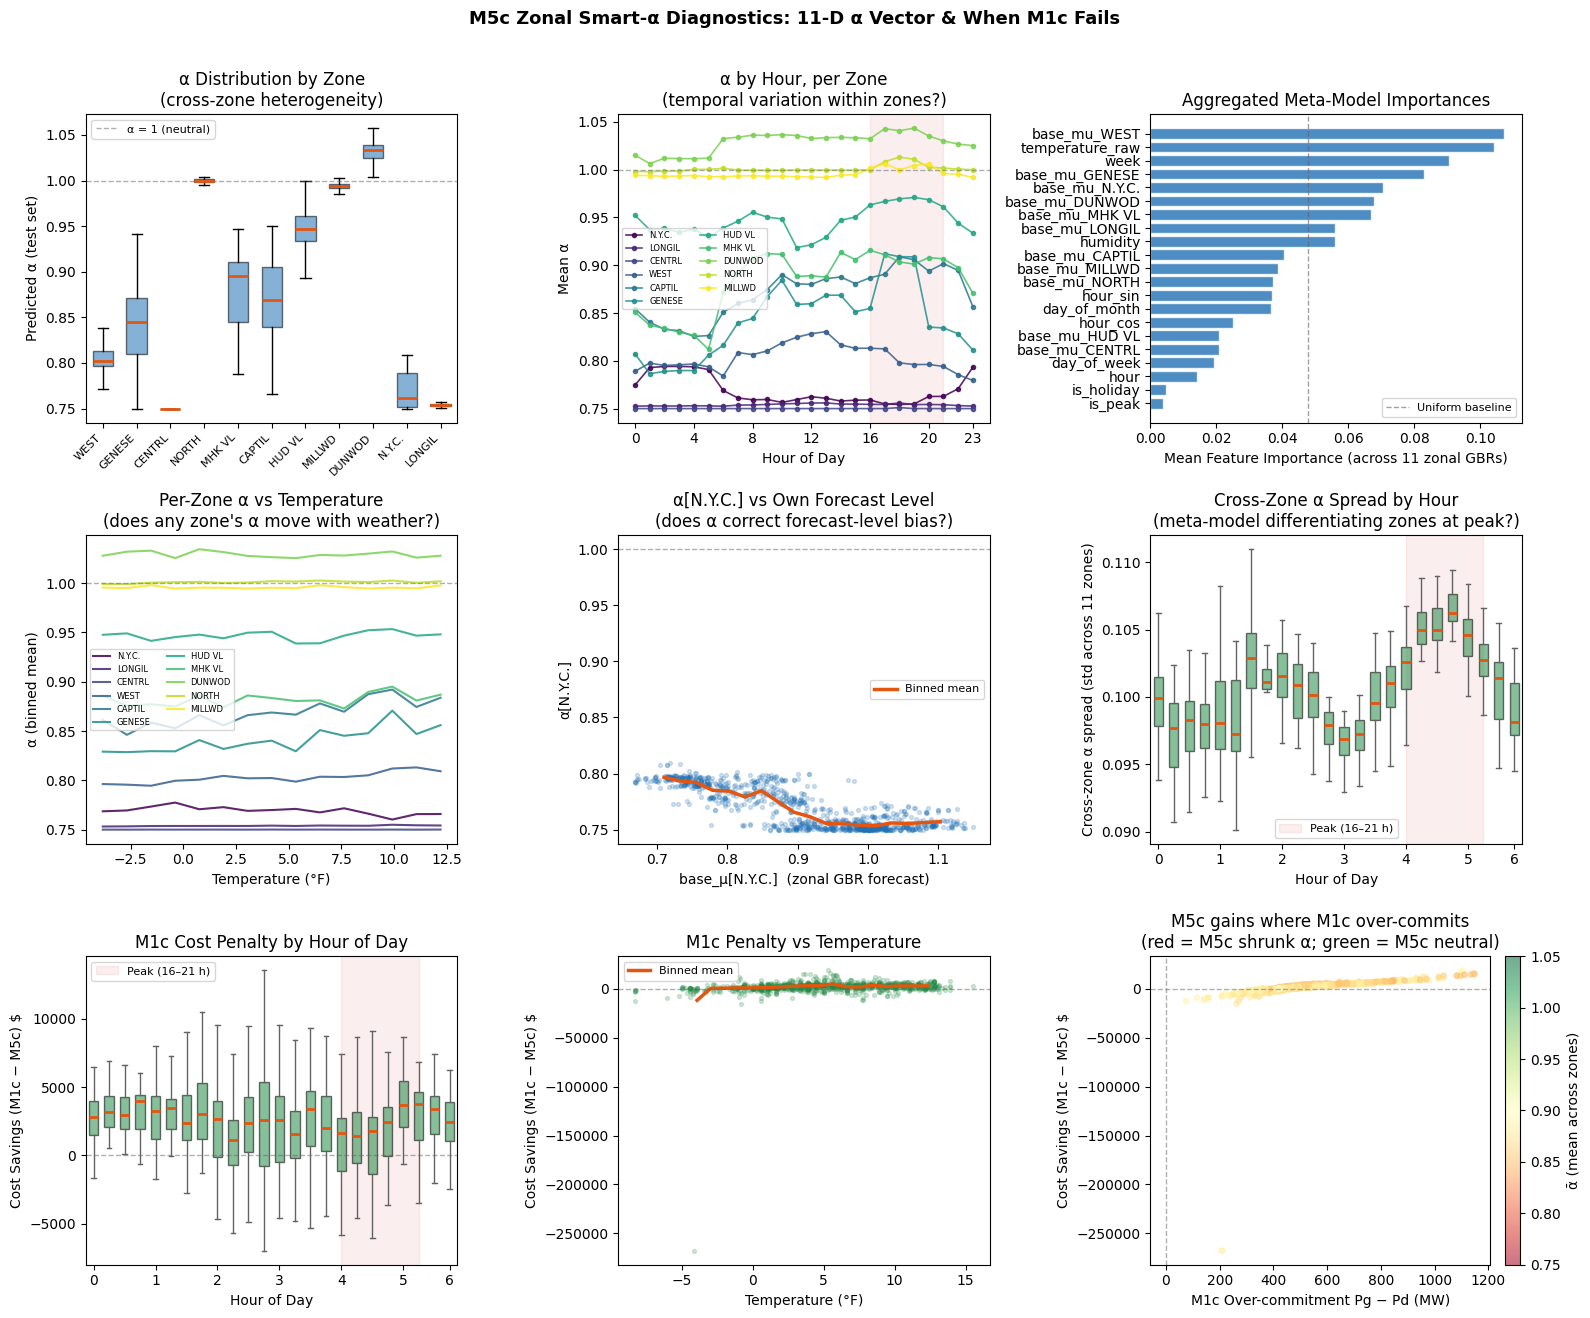

Saved m5c_alpha_diagnostics.png


In [201]:
# =============================================================================
# M5c Zonal Smart-Alpha Diagnostics
#
# Three questions answered visually:
#   1. What has the meta-model learned?
#      - Per-zone α distribution, hourly profile, aggregated feature importances
#   2. How does each zone's α respond to grid conditions?
#      - α[z] vs temperature, α[z] vs zone's own forecast level, cross-zone spread
#   3. When does M1c fail and M5c recover?
#      - Cost gap by hour, vs temperature, vs M1c over-commitment
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binned_statistic

# ── Assemble M5c diagnostic DataFrame ──────────────────────────────────────
diag = all_test_feats_m5c.copy()                          # index = test_timestamps
diag["hour_int"] = diag["hour"].astype(int)
diag["temperature_raw"] = df.loc[test_timestamps, "temperature_raw"].values

# Per-zone alpha columns (11 of them)
for zi, z in enumerate(ZONE_NAMES):
    diag[f"alpha_{z}"] = predicted_alphas_m5c[:, zi]

# Per-timestamp summaries of the 11-D alpha vector
diag["alpha_mean"] = predicted_alphas_m5c.mean(axis=1)    # avg α across zones
diag["alpha_std"]  = predicted_alphas_m5c.std(axis=1)     # cross-zone spread

# Merge realized costs from M1c and M5c
_cols = ["total_realized", "shed_mw", "stage2_cost_realized", "delta_mw"]
_r1c = results_m1c.set_index("ts")[_cols]
_r5c = results_m5c.set_index("ts")[_cols]
diag = diag.join(_r1c.rename(columns=lambda c: c + "_m1c"), how="inner")
diag = diag.join(_r5c.rename(columns=lambda c: c + "_m5c"), how="inner")
diag["cost_gap"] = diag["total_realized_m1c"] - diag["total_realized_m5c"]  # positive = M5c wins

print(f"Diagnostic set        : {len(diag)} timestamps")
print(f"Mean ᾱ across zones   : {diag['alpha_mean'].mean():.4f}")
print(f"Cross-zone α spread   : {diag['alpha_std'].mean():.4f} (mean per timestamp)")
print(f"Frac ᾱ > 1            : {(diag['alpha_mean'] > 1).mean():.1%}")
print(f"Mean cost gap         : ${diag['cost_gap'].mean():,.1f}  (M1c − M5c)")

# ── Colors & helpers ───────────────────────────────────────────────────────
BLUE, ORANGE, GREEN, GREY, RED = "#2171b5", "#e6550d", "#238b45", "#636363", "#cb181d"
FOCUS_ZONE = "N.Y.C."  # largest NYISO median; biggest cost lever

# Order zones by NYISO median load (largest first) — gives meaningful color gradient
zone_order_for_plot = [ZONE_NAMES[i] for i in np.argsort(-zonal_df.median().values)]
cmap = plt.cm.viridis

def _binned_mean(x, y, n_bins=18, pct=(2, 98)):
    lo, hi = np.nanpercentile(x, pct[0]), np.nanpercentile(x, pct[1])
    edges = np.linspace(lo, hi, n_bins + 1)
    mask = (~np.isnan(x)) & (~np.isnan(y))
    means, edges, _ = binned_statistic(x[mask], y[mask], statistic="mean", bins=edges)
    return 0.5 * (edges[:-1] + edges[1:]), means

def _hour_boxes(series, ax, color, ylabel="", title=""):
    groups = [series[diag["hour_int"] == h].values for h in range(24)]
    ax.boxplot(groups, positions=range(24), widths=0.6, showfliers=False,
               patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.55),
               medianprops=dict(color=ORANGE, lw=2),
               whiskerprops=dict(color=GREY), capprops=dict(color=GREY))
    ax.axvspan(16, 21, alpha=0.07, color=RED, label="Peak (16–21 h)")
    ax.set_xticks([0, 4, 8, 12, 16, 20, 23])
    ax.set_xlabel("Hour of Day"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=8)

# ── Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle("M5c Zonal Smart-α Diagnostics: 11-D α Vector & When M1c Fails",
             fontsize=13, fontweight="bold", y=1.01)

# ── Row 1: What has the meta-model learned? ────────────────────────────────

# 1-1  α distribution by zone
ax = axes[0, 0]
zdata = [diag[f"alpha_{z}"].values for z in ZONE_NAMES]
bp = ax.boxplot(zdata, patch_artist=True, showfliers=False, widths=0.6,
                boxprops=dict(facecolor=BLUE, alpha=0.55),
                medianprops=dict(color=ORANGE, lw=2))
ax.axhline(1.0, color=GREY, lw=1, ls="--", alpha=0.5, label="α = 1 (neutral)")
ax.set_xticks(range(1, len(ZONE_NAMES) + 1))
ax.set_xticklabels(ZONE_NAMES, rotation=45, fontsize=8, ha="right")
ax.set_ylabel("Predicted α (test set)")
ax.set_title("α Distribution by Zone\n(cross-zone heterogeneity)")
ax.legend(fontsize=8)

# 1-2  α by hour, one line per zone
ax = axes[0, 1]
for i, z in enumerate(zone_order_for_plot):
    hourly = diag.groupby("hour_int")[f"alpha_{z}"].mean()
    ax.plot(hourly.index, hourly.values, marker="o", ms=3, lw=1.2,
            label=z, color=cmap(i / (N_ZONES - 1)), alpha=0.85)
ax.axhline(1.0, color=GREY, lw=1, ls="--", alpha=0.5)
ax.axvspan(16, 21, alpha=0.07, color=RED)
ax.set_xticks([0, 4, 8, 12, 16, 20, 23])
ax.set_xlabel("Hour of Day"); ax.set_ylabel("Mean α")
ax.set_title("α by Hour, per Zone\n(temporal variation within zones?)")
ax.legend(fontsize=6, ncol=2, loc="best")

# 1-3  Aggregated feature importances (mean over the 11 zonal GBRs)
ax = axes[0, 2]
feat_names = list(alpha_features_m5c.columns)
imp_matrix = np.vstack([est.feature_importances_ for est in meta_model_m5c.estimators_])
mean_imp = imp_matrix.mean(axis=0)
order = np.argsort(mean_imp)
ax.barh([feat_names[i] for i in order], mean_imp[order],
        color=BLUE, alpha=0.8, edgecolor="white")
ax.axvline(1.0 / len(feat_names), color=GREY, lw=1, ls="--", alpha=0.6,
           label="Uniform baseline")
ax.set_xlabel("Mean Feature Importance (across 11 zonal GBRs)")
ax.set_title("Aggregated Meta-Model Importances")
ax.legend(fontsize=8)

# ── Row 2: How does α respond to grid conditions? ──────────────────────────
temp_v = diag["temperature_raw"].values

# 2-1  Per-zone α vs Temperature (binned-mean lines, no scatter)
ax = axes[1, 0]
for i, z in enumerate(zone_order_for_plot):
    cx, cy = _binned_mean(temp_v, diag[f"alpha_{z}"].values, n_bins=15)
    ax.plot(cx, cy, lw=1.5, color=cmap(i / (N_ZONES - 1)), label=z, alpha=0.85)
ax.axhline(1.0, color=GREY, lw=1, ls="--", alpha=0.5)
ax.set_xlabel("Temperature (°F)"); ax.set_ylabel("α (binned mean)")
ax.set_title("Per-Zone α vs Temperature\n(does any zone's α move with weather?)")
ax.legend(fontsize=6, ncol=2, loc="best")

# 2-2  Focus zone α vs that zone's own forecast level
ax = axes[1, 1]
focus_alpha = diag[f"alpha_{FOCUS_ZONE}"].values
focus_mu    = diag[f"base_mu_{FOCUS_ZONE}"].values
ax.scatter(focus_mu, focus_alpha, alpha=0.2, s=8, color=BLUE)
cx, cy = _binned_mean(focus_mu, focus_alpha)
ax.plot(cx, cy, color=ORANGE, lw=2.5, label="Binned mean")
ax.axhline(1.0, color=GREY, lw=1, ls="--", alpha=0.5)
ax.set_xlabel(f"base_μ[{FOCUS_ZONE}]  (zonal GBR forecast)")
ax.set_ylabel(f"α[{FOCUS_ZONE}]")
ax.set_title(f"α[{FOCUS_ZONE}] vs Own Forecast Level\n"
             f"(does α correct forecast-level bias?)")
ax.legend(fontsize=8)

# 2-3  Cross-zone spread of α by hour (does the model differentiate zones differently?)
ax = axes[1, 2]
_hour_boxes(diag["alpha_std"], ax, GREEN,
            ylabel="Cross-zone α spread (std across 11 zones)",
            title="Cross-Zone α Spread by Hour\n(meta-model differentiating zones at peak?)")

# ── Row 3: When does M1c fail and M5c recover? ─────────────────────────────
gap_v = diag["cost_gap"].values

# 3-1  Cost gap by hour
ax = axes[2, 0]
_hour_boxes(diag["cost_gap"], ax, GREEN,
            ylabel="Cost Savings (M1c − M5c) $",
            title="M1c Cost Penalty by Hour of Day")
ax.axhline(0, color=GREY, lw=1, ls="--", alpha=0.5)

# 3-2  Cost gap vs Temperature
ax = axes[2, 1]
ax.scatter(temp_v, gap_v, alpha=0.2, s=8, color=GREEN)
cx, cy = _binned_mean(temp_v, gap_v)
ax.plot(cx, cy, color=ORANGE, lw=2.5, label="Binned mean")
ax.axhline(0, color=GREY, lw=1, ls="--", alpha=0.5)
ax.set_xlabel("Temperature (°F)")
ax.set_ylabel("Cost Savings (M1c − M5c) $")
ax.set_title("M1c Penalty vs Temperature")
ax.legend(fontsize=8)

# 3-3  M1c over-commitment vs cost gap, colored by ᾱ
# delta_mw < 0 means Pg_star > Pd_actual (over-committed). Flip sign so x ≥ 0 = over-commit.
ax = axes[2, 2]
overcommit_m1c = -diag["delta_mw_m1c"].values
sc = ax.scatter(overcommit_m1c, gap_v,
                c=diag["alpha_mean"], cmap="RdYlGn",
                alpha=0.55, s=15, vmin=0.75, vmax=1.05)
ax.axhline(0, color=GREY, lw=1, ls="--", alpha=0.5)
ax.axvline(0, color=GREY, lw=1, ls="--", alpha=0.5)
plt.colorbar(sc, ax=ax, label="ᾱ (mean across zones)", fraction=0.046, pad=0.04)
ax.set_xlabel("M1c Over-commitment Pg − Pd (MW)")
ax.set_ylabel("Cost Savings (M1c − M5c) $")
ax.set_title("M5c gains where M1c over-commits\n(red = M5c shrunk α; green = M5c neutral)")

fig.tight_layout()
plt.savefig("m5c_alpha_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved m5c_alpha_diagnostics.png")

In [ ]:
'''# ============================================================================
# Model 6 (fast, serial): Quantile parameterization + KKT duals + Brent search
# ============================================================================
import os
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.ensemble import GradientBoostingRegressor
from scipy.optimize import minimize_scalar
from scipy.stats import lognorm

print("\n>>> Building Model 6 (fast, serial)...")

# ---------------- Hyperparameters ----------------
N_LABELS       = 400
N_LABEL_SCEN   = 150
N_INFER_SCEN   = 100
Q_LO, Q_HI     = 0.50, 0.9995
Q_TOL          = 5e-3
BRENT_MAXITER  = 12

# ---------------- CRN draws ----------------
_m6_rng_lab = np.random.default_rng(2028)
_m6_rng_inf = np.random.default_rng(2029)
eps_label = lognorm.rvs(sh_r, lo_r, sc_r, size=N_LABEL_SCEN, random_state=_m6_rng_lab)
eps_infer = lognorm.rvs(sh_r, lo_r, sc_r, size=N_INFER_SCEN, random_state=_m6_rng_inf)

# ---------------- Solvers ----------------
fast_label_s1 = FastStochasticOPF(N_SCEN=N_LABEL_SCEN, voll=VOLL, c_curt=C_CURT, verbose=False)
fast_infer_s1 = FastStochasticOPF(N_SCEN=N_INFER_SCEN, voll=VOLL, c_curt=C_CURT, verbose=False)
fast_dual_s1  = FastStochasticOPF(N_SCEN=1, voll=VOLL, c_curt=C_CURT, verbose=False)
fast_s2       = FastRealizedStage2(voll=VOLL, c_curt=C_CURT)


# ---------------- Helpers ----------------
def extract_dual_features(solve_result):
    duals = solve_result.get("duals", {}) or {}

    def _summ(arr):
        if arr is None:
            return [0.0, 0.0, 0.0, 0.0]
        a = np.asarray(arr, dtype=float).ravel()
        if a.size == 0:
            return [0.0, 0.0, 0.0, 0.0]
        return [a.mean(), a.max(), a.std(), float((a > 1e-6).sum())]

    feats = []
    for k in ["balance", "pg_max", "pg_min", "line", "volt"]:
        feats += _summ(duals.get(k))
    return np.array(feats, dtype=float)


DUAL_FEAT_NAMES = [f"dual_{g}_{s}"
                   for g in ["bal", "pgmax", "pgmin", "line", "volt"]
                   for s in ["mean", "max", "std", "nbind"]]


def pd_hat_at_quantile(mu, q):
    """Stage-1 dispatch target = q-th quantile of conditional demand."""
    return mu * lognorm.ppf(q, sh_r, lo_r, sc_r) * _BASE_BUS


def cheap_duals(mu):
    """Deterministic 1-scenario OPF at q=0.5 → dual feature vector."""
    Pd_med = pd_hat_at_quantile(mu, 0.5)
    scen_1 = (mu * lognorm.median(sh_r, lo_r, sc_r) * _BASE_BUS)[None, :]
    r = fast_dual_s1.solve(Pd_med, scen_1)
    return extract_dual_features(r)


def label_one(ts):
    """Brent search for cost-optimal q at a single timestamp + cheap duals."""
    feats_row = df.loc[[ts], FEATS].values
    base_mu   = float(gbr.predict(feats_row)[0])
    Pd_actual = pd_actual_at(ts)
    scen      = np.outer(base_mu * eps_label, _BASE_BUS)

    duals = cheap_duals(base_mu)

    def realized_cost(q):
        Pd_hat = pd_hat_at_quantile(base_mu, q)
        r1 = fast_label_s1.solve(Pd_hat, scen)
        r2 = fast_s2.solve(r1["Pg"], Pd_actual)
        return r1["stage1_cost"] + r2["stage2_cost"]

    res = minimize_scalar(realized_cost, bounds=(Q_LO, Q_HI), method="bounded",
                          options={"xatol": Q_TOL, "maxiter": BRENT_MAXITER})
    return float(res.x), duals


def build_meta_features(timestamps):
    X = df.loc[timestamps, FEATS].copy()
    X["base_mu"]  = gbr.predict(X.values)
    X["humidity"] = df.loc[timestamps, "humidity"].values
    X["hour_sin"] = np.sin(2 * np.pi * X["hour"] / 24)
    X["hour_cos"] = np.cos(2 * np.pi * X["hour"] / 24)
    X["is_peak"]  = ((X["hour"] >= 16) & (X["hour"] <= 21)).astype(int)
    return X


def to_logit(q):   return np.log(q / (1.0 - q))
def from_logit(z): return 1.0 / (1.0 + np.exp(-z))


# ============================================================================
# BUDGET CHECK
# ============================================================================
print("\n[budget check] Timing one labeled timestamp...")
_ts0 = train_df.index[len(train_df) // 2]
_t0  = time.time()
label_one(_ts0)
sec_per_label = time.time() - _t0
est_phase1 = sec_per_label * N_LABELS / 60
print(f"  ~{sec_per_label:.2f}s per label, "
      f"est. Phase 1 (serial): {est_phase1:.1f} min")
if est_phase1 > 50:
    print("  WARNING: drop N_LABELS or N_LABEL_SCEN before continuing.")


# ============================================================================
# PHASE 1: Brent search per labeled timestamp
# ============================================================================
print(f"\nPhase 1: Brent over {N_LABELS} timestamps "
      f"(N_LABEL_SCEN={N_LABEL_SCEN})...")

label_timestamps = train_df.sample(n=N_LABELS, random_state=42).index.sort_values()

q_star_labels    = []
dual_feat_labels = []
_phase1_t0 = time.time()
for ts in tqdm(label_timestamps, desc="Phase 1 (labels)"):
    q_star, duals = label_one(ts)
    q_star_labels.append(q_star)
    dual_feat_labels.append(duals)
q_star_labels    = np.array(q_star_labels)
dual_feat_labels = np.vstack(dual_feat_labels)
print(f"  Phase 1 wall time: {(time.time() - _phase1_t0)/60:.1f} min")
print(f"  q* dist: mean={q_star_labels.mean():.4f}, "
      f"median={np.median(q_star_labels):.4f}, "
      f"5/95 pct=[{np.percentile(q_star_labels, 5):.4f}, "
      f"{np.percentile(q_star_labels, 95):.4f}]")


# ============================================================================
# PHASE 2: Meta-model on (raw features + duals) -> logit(q*)
# ============================================================================
print("\nPhase 2: training meta-model...")

X_label = np.hstack([build_meta_features(label_timestamps).values, dual_feat_labels])
y_label_logit = to_logit(np.clip(q_star_labels, 1e-4, 1 - 1e-4))

meta_model_m6 = GradientBoostingRegressor(
    n_estimators=400, max_depth=3, learning_rate=0.03,
    subsample=0.8, min_samples_leaf=15,
    random_state=42, validation_fraction=0.15, n_iter_no_change=25,
)
meta_model_m6.fit(X_label, y_label_logit)
print(f"  early-stopped at n_estimators_used = {meta_model_m6.n_estimators_}")


# ============================================================================
# PHASE 3: Cheap dual extraction on test set + inference
# ============================================================================
print("\nPhase 3: cheap (1-scenario) dual extraction on test set...")

X_test_raw = build_meta_features(test_timestamps)
all_mu     = X_test_raw["base_mu"].values

_phase3_t0 = time.time()
dual_feat_test = np.vstack([
    cheap_duals(float(mu_i))
    for mu_i in tqdm(all_mu, desc="Phase 3 (test duals)")
])
print(f"  Phase 3 wall time: {(time.time() - _phase3_t0)/60:.1f} min")

X_test      = np.hstack([X_test_raw.values, dual_feat_test])
q_pred_test = np.clip(from_logit(meta_model_m6.predict(X_test)), Q_LO, Q_HI)

m6_pd_dict = {ts: (float(mu_i), float(q_i))
              for ts, mu_i, q_i in zip(test_timestamps, all_mu, q_pred_test)}


def predict_m6_quantile_duals(ts):
    mu_i, q_i = m6_pd_dict[ts]
    Pd_hat = pd_hat_at_quantile(mu_i, q_i)
    # Scenarios are HONEST — drawn from the true conditional distribution,
    # not biased by q. Only Pd_hat is shifted to hedge load-shed cost.
    scen = np.outer(mu_i * eps_infer, _BASE_BUS)
    return Pd_hat, scen


# --- Evaluation ---
print("\n>>> Evaluating Model 6 (fast, serial) over test set...")
results_m6 = evaluate_model("M6_quantile_duals_fast", predict_m6_quantile_duals, test_timestamps)

print("\nModel 6 summary:")
print(summarize_results(results_m6).to_string())
all_model_results["M6_quantile_duals_fast"] = results_m6

print(f"\n  predicted q* on test: mean={q_pred_test.mean():.4f}, "
      f"5/95 pct = [{np.percentile(q_pred_test, 5):.4f}, "
      f"{np.percentile(q_pred_test, 95):.4f}]")'''


>>> Building Model 6 (fast, serial)...


/var/folders/nn/n3_8rlvx6h9bxwg2t6d_0xth0000gn/T/ipykernel_92660/4039276040.py:114: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),



[budget check] Timing one labeled timestamp...
  ~4.72s per label, est. Phase 1 (serial): 31.5 min

Phase 1: Brent over 400 timestamps (N_LABEL_SCEN=150)...


Phase 1 (labels):   4%|▍         | 15/400 [01:19<33:57,  5.29s/it]


Interrupt request received


RuntimeError: Gurobi Status=11

## <span style = "color:green"> Final Model Results / Compaison </span>

MODEL COMPARISON SUMMARY
                         Mean Total ($) Std ($)              95% CI Stage-1 ($) Stage-2 realized ($) Shed MW Frac shed>1 MW
Model                                                                                                                      
M1_lognormal                    111,823  55,455  [108,382, 115,264]     108,620                3,203    0.00           0.0%
M1c_zonal_gbr_copula             79,823  10,247    [79,187, 80,459]      90,334              -10,511    0.00           0.0%
M5c_zonal_decision_aware         77,626  15,054    [76,691, 78,560]      74,510                3,116    0.02           0.1%
Oracle                           76,108  10,619    [75,449, 76,766]      76,108                    0    0.00           0.0%


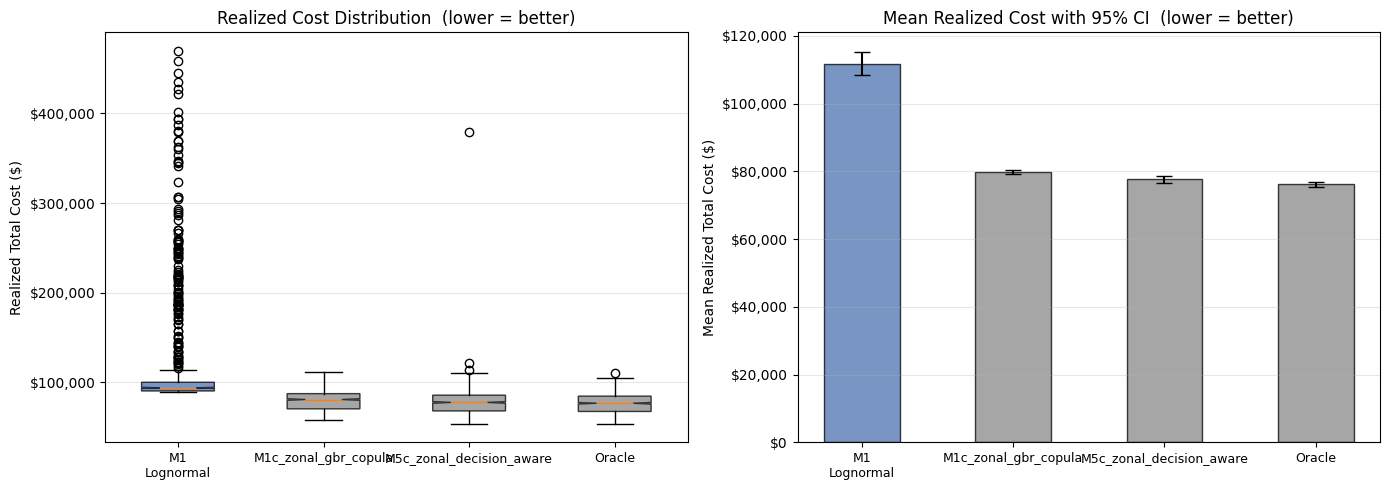

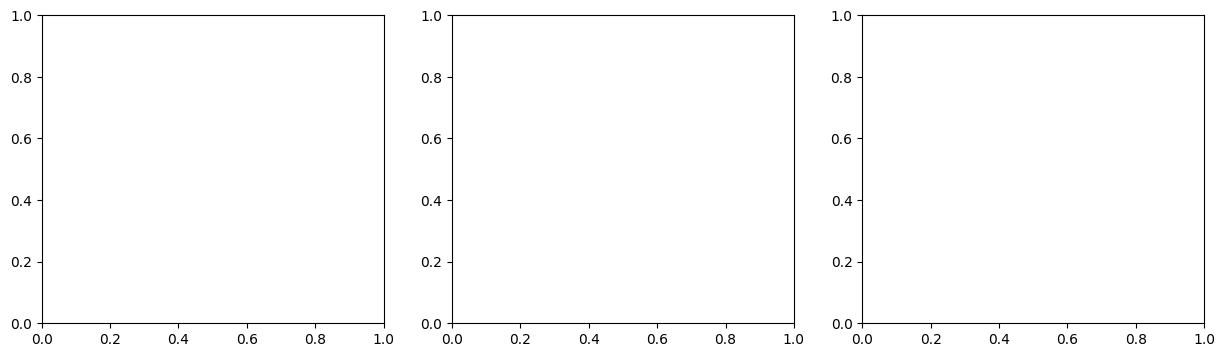

In [200]:
# =============================================================================
# Final Comparison: All Models Side-by-Side
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- 1. Summary table ---
comparison_rows = []
for name, res_df in all_model_results.items():
    s = summarize_results(res_df)
    comparison_rows.append({
        "Model":              name,
        "Mean Total ($)":     f"{s['mean_total']:,.0f}",
        "Std ($)":            f"{s['std_total']:,.0f}",
        "95% CI":             f"[{s['ci_lo']:,.0f}, {s['ci_hi']:,.0f}]",
        "Stage-1 ($)":        f"{s['mean_stage1']:,.0f}",
        "Stage-2 realized ($)": f"{s['mean_stage2']:,.0f}",
        "Shed MW":            f"{s['mean_shed_mw']:.2f}",
        "Frac shed>1 MW":     f"{s['frac_shed_gt1']:.1%}",
    })
cmp_df = pd.DataFrame(comparison_rows).set_index("Model")
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(cmp_df.to_string())

# --- 2. Cost distribution: box + mean-CI bar ---
model_order = list(all_model_results.keys())

# Derived from model_order so counts always match, regardless of which models have run
_label_map = {
    "M1_lognormal":              "M1\nLognormal",
    "M1b_gbr_lognormal":         "M1b\nGBR+LogNorm",
    "M2_ngboost":                "M2\nNGBoost",
    "M4_smart_alpha":            "M4\nSmart-α",
    "M5_meta":                   "M5\nMeta",
    "M6_quantile_duals_fast":    "M6\nQuantile\nDuals",
}
_color_map = {
    "M1_lognormal":              "#4C72B0",
    "M1b_gbr_lognormal":         "#DD8452",
    "M2_ngboost":                "#55A868",
    "M4_smart_alpha":            "#C44E52",
    "M5_meta":                   "#9467BD",
    "M6_quantile_duals_fast":    "#8C564B",
}
labels = [_label_map.get(m, m) for m in model_order]
colors = [_color_map.get(m, "#888888") for m in model_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
ax = axes[0]
data_boxes = [all_model_results[m]["total_realized"].values for m in model_order]
bp = ax.boxplot(data_boxes, patch_artist=True, notch=True, widths=0.5)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticks(range(1, len(model_order) + 1))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Realized Total Cost ($)")
ax.set_title("Realized Cost Distribution  (lower = better)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(axis="y", alpha=0.3)

# Mean + 95% CI bar chart
ax2 = axes[1]
summaries = [summarize_results(all_model_results[m]) for m in model_order]
means     = [s["mean_total"] for s in summaries]
errs_lo   = [s["mean_total"] - s["ci_lo"] for s in summaries]
errs_hi   = [s["ci_hi"] - s["mean_total"] for s in summaries]

x = range(len(model_order))
ax2.bar(x, means, color=colors, alpha=0.75, edgecolor="black", width=0.5)
ax2.errorbar(x, means, yerr=[errs_lo, errs_hi],
             fmt="none", color="black", capsize=6, linewidth=1.5)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel("Mean Realized Total Cost ($)")
ax2.set_title("Mean Realized Cost with 95% CI  (lower = better)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# --- 3. Alpha variation across the full test set ---
_af = _test_feats.copy()

_af["humidity"]   = df.loc[_af.index, "humidity"]
_af["hour_sin"]   = np.sin(2 * np.pi * _af["hour"] / 24)
_af["hour_cos"]   = np.cos(2 * np.pi * _af["hour"] / 24)
_af["is_peak"]    = ((_af["hour"] >= 16) & (_af["hour"] <= 21)).astype(int)


fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))



In [ ]:
# =============================================================================
# STRESS-TEST EVALUATION: Top 5% Highest Actual Demand
#
# No retraining. All models are evaluated AS-IS on 100 timestamps drawn from
# the top 5th-percentile of actual system load within the held-out test pool.
# These are the hardest cases for any dispatch model — the scenarios where
# forecast errors are costliest and reserve adequacy matters most.
# M4's covariate-conditioned alpha should shine here precisely because
# high temperature / peak-hour conditions reliably push demand above the base
# NGBoost forecast, and the alpha layer was trained to correct for exactly that.
# =============================================================================
import matplotlib.ticker as mticker   # safe re-import in case cell order varies

# --- 1. Identify the top 5% of test pool by actual system load ---
_test_loads = df.loc[test_df.index, 'load_mw']
_p95        = _test_loads.quantile(0.95)
_high_pool  = test_df.loc[_test_loads >= _p95]

print(f"Full test pool:       {len(test_df):,} timestamps")
print(f"95th-pctile load:     {_p95:,.1f} MW")
print(f"High-demand pool:     {len(_high_pool):,} timestamps "
      f"({100*len(_high_pool)/len(test_df):.1f}% of test set)")

_rng_stress       = np.random.default_rng(77)
_n_stress         = min(100, len(_high_pool))
_stress_idx       = _rng_stress.choice(len(_high_pool), size=_n_stress, replace=False)
stress_timestamps = _high_pool.index[np.sort(_stress_idx)]

print(f"Stress-test set:      {_n_stress} timestamps")
print(f"  Mean load (stress): {df.loc[stress_timestamps, 'load_mw'].mean():,.1f} MW")
print(f"  Mean load (random): {df.loc[test_timestamps,   'load_mw'].mean():,.1f} MW")

# --- 2. Rebuild lookup dicts for conditional models over stress_timestamps ---
#        predict_m1 is unconditional — no rebuild needed.
_sf_arr = df.loc[stress_timestamps, FEATS].values   # shared base feature matrix

# M1b: GBR conditional mean
_mu_stress_m1b      = gbr.predict(_sf_arr)
_mu_dict_stress_m1b = dict(zip(stress_timestamps, _mu_stress_m1b))

def predict_m1b_stress(ts):
    mu = _mu_dict_stress_m1b[ts]
    return mu * _BASE_BUS, np.outer(mu * eps_base, _BASE_BUS)

# M2: NGBoost conditional lognormal
_Y_stress_m2 = ngb.pred_dist(_sf_arr)
_med_s_m2    = dict(zip(stress_timestamps, _Y_stress_m2.params['scale']))
_sig_s_m2    = dict(zip(stress_timestamps, _Y_stress_m2.params['s']))

def predict_m2_stress(ts):
    sf_median = float(_med_s_m2[ts])
    sf_sigma  = float(_sig_s_m2[ts])
    mu_log    = np.log(sf_median)
    sf_mean   = np.exp(mu_log + (sf_sigma**2) / 2.0)
    sf_scens  = np.exp(mu_log + sf_sigma * Z_base_m2)
    return sf_mean * _BASE_BUS, np.outer(sf_scens, _BASE_BUS)

# M4: Smart-Alpha — rebuild full alpha feature matrix for stress timestamps
_af_stress = df.loc[stress_timestamps, FEATS].copy()
_Yd_stress = ngb.pred_dist(_af_stress.values)
_af_stress['base_mu']    = _Yd_stress.params['scale']
_af_stress['base_sigma'] = _Yd_stress.params['s']
_af_stress['humidity']   = df.loc[stress_timestamps, 'humidity'].values
_af_stress['hour_sin']   = np.sin(2 * np.pi * _af_stress['hour'] / 24)
_af_stress['hour_cos']   = np.cos(2 * np.pi * _af_stress['hour'] / 24)
_af_stress['is_peak']    = ((_af_stress['hour'] >= 16) &
                             (_af_stress['hour'] <= 21)).astype(int)
_alpha_stress = alpha_model.predict(_af_stress.values)
_mu_s_m4  = dict(zip(stress_timestamps, _af_stress['base_mu'] * _alpha_stress))
_sig_s_m4 = dict(zip(stress_timestamps, _af_stress['base_sigma']))

def predict_m4_stress(ts):
    final_mu   = _mu_s_m4[ts]
    base_sigma = _sig_s_m4[ts]
    mu_log     = np.log(final_mu)
    sf_scens   = np.exp(mu_log + base_sigma * Z_base)
    return final_mu * _BASE_BUS, np.outer(sf_scens, _BASE_BUS)

# --- 3. Evaluate all models on stress set ---
_stress_fns = {
    "M1_lognormal":      predict_m1,
    "M1b_gbr_lognormal": predict_m1b_stress,
    "M2_ngboost":        predict_m2_stress,
    "M4_smart_alpha":    predict_m4_stress,
}

stress_results = {}
for _mname, _pfn in _stress_fns.items():
    print(f"\n>>> [{_mname}] stress-test evaluation ...")
    stress_results[_mname] = evaluate_model(_mname, _pfn, stress_timestamps)

# --- 4. Summary table ---
print("\n" + "=" * 70)
print(f"STRESS-TEST RESULTS  (top 5% demand, n={_n_stress})")
print("=" * 70)
_stress_rows = []
for _nm, _res in stress_results.items():
    _s = summarize_results(_res)
    _stress_rows.append({
        "Model":                _nm,
        "Mean Total ($)":       f"{_s['mean_total']:,.0f}",
        "Std ($)":              f"{_s['std_total']:,.0f}",
        "95% CI":               f"[{_s['ci_lo']:,.0f}, {_s['ci_hi']:,.0f}]",
        "Stage-2 realized ($)": f"{_s['mean_stage2']:,.0f}",
        "Shed MW":              f"{_s['mean_shed_mw']:.2f}",
        "Frac shed>1 MW":       f"{_s['frac_shed_gt1']:.1%}",
    })
print(pd.DataFrame(_stress_rows).set_index("Model").to_string())

print("\nM4 improvement over baselines on high-demand scenarios:")
_m4_mean = summarize_results(stress_results["M4_smart_alpha"])["mean_total"]
for _nm in ["M1_lognormal", "M1b_gbr_lognormal", "M2_ngboost"]:
    _base = summarize_results(stress_results[_nm])["mean_total"]
    _sav  = _base - _m4_mean
    print(f"  vs {_nm:<22}: ${_sav:+,.0f}  ({100*_sav/_base:+.2f}%)")

# --- 5. Side-by-side: random test vs stress test ---
_model_order = list(stress_results.keys())
_labels      = ["M1\nLognormal", "M1b\nGBR+LogNorm", "M2\nNGBoost", "M4\nSmart-\u03b1"]
_colors      = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (rdict, title) in zip(axes, [
    (all_model_results, f"Random test  (n={N_TEST})"),
    (stress_results,    f"High-demand stress test  (n={_n_stress}, top 5%)"),
]):
    _boxes = [rdict[m]["total_realized"].values for m in _model_order]
    _bp    = ax.boxplot(_boxes, patch_artist=True, notch=True, widths=0.5)
    for patch, color in zip(_bp["boxes"], _colors):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(_model_order) + 1))
    ax.set_xticklabels(_labels, fontsize=9)
    ax.set_ylabel("Realized Total Cost ($)")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Random vs High-Demand Stress Test  (lower = better)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

Full test pool:       13,824 timestamps
95th-pctile load:     4,997.1 MW
High-demand pool:     692 timestamps (5.0% of test set)
Stress-test set:      100 timestamps
  Mean load (stress): 5,357.6 MW
  Mean load (random): 3,678.0 MW


NameError: name 'ngb' is not defined

In [199]:
# =============================================================================
# Oracle (Perfect Foresight) — Lower Bound on Realized Cost
#
# This model cheats: it uses the actual realized demand as both its point
# prediction AND its single scenario.  Stage 1 is therefore solved with
# exact knowledge of what will happen, giving the best possible first-stage
# commitment.  Stage 2 recourse cost should be near zero (no surprise).
# The result is a theoretical lower bound for all other models.
# =============================================================================

def predict_oracle(ts):
    """Perfect-foresight oracle: predict exactly the realized demand."""
    Pd_actual = pd_actual_at(ts)
    # Single scenario = the exact realized demand vector
    node_scen = Pd_actual.reshape(1, -1)
    return Pd_actual, node_scen

print(">>> Evaluating Oracle (perfect foresight) over test set...")
results_oracle = evaluate_model("Oracle", predict_oracle, test_timestamps)

print("Oracle summary:")
print(summarize_results(results_oracle).to_string())

# Register in the shared results dict so the final comparison cells can pick it up
all_model_results["Oracle"] = results_oracle


>>> Evaluating Oracle (perfect foresight) over test set...


Eval Oracle:   0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/nn/n3_8rlvx6h9bxwg2t6d_0xth0000gn/T/ipykernel_92660/4039276040.py:114: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),
Eval Oracle: 100%|██████████| 1000/1000 [00:01<00:00, 870.33it/s]

Oracle summary:
n                     1.000000e+03
mean_total            7.610752e+04
std_total             1.061901e+04
ci_lo                 7.544856e+04
ci_hi                 7.676648e+04
mean_stage1           7.610752e+04
mean_stage2           5.869794e-12
mean_shed_mw          0.000000e+00
mean_curt_mw          0.000000e+00
mean_ramp_mw          3.946550e-13
frac_shed_gt1         0.000000e+00
mean_ac_losses_mw              NaN
mean_v_min                     NaN
mean_v_max                     NaN
frac_ac_infeasible             NaN


In [ ]:

# =============================================================================
# AC Stage-2 Evaluation: DC-Trained Commitment vs AC-OPF Realized Cost
#
# Research question: How much does training against a DC-relaxation under-estimate
# true operational costs? What is the "DC relaxation gap"?
#
# Architecture:
#   Stage-1 (unchanged): DC stochastic OPF → Pg_star  (fast, linear, Gurobi)
#   Stage-2 (NEW):       AC power flow recourse       (nonlinear, IPOPT)
#
# Models evaluated: M1, M1b, M5, Oracle
# M2/M6 excluded intentionally (NGBoost dependency / commented out elsewhere)
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from tqdm import tqdm

print("=" * 60)
print("AC Stage-2 Evaluation")
print(f"IPOPT available: {_ac_stage2_solver._ipopt_available}")
print("=" * 60)

if not _ac_stage2_solver._ipopt_available:
    print("\nWARNING: IPOPT not found. Install with: conda install -c conda-forge ipopt")
    print("AC results will be DC approximations (identical to DC evaluation).")
    print("To install on macOS: brew install ipopt  or  conda install ipopt")

# Use a smaller subset for AC evaluation — IPOPT is ~50-100x slower than Gurobi LP
N_AC_TEST = min(100, N_TEST)
_rng_ac   = np.random.default_rng(999)
_ac_idx   = _rng_ac.choice(len(test_timestamps), size=N_AC_TEST, replace=False)
ac_test_timestamps = test_timestamps[np.sort(_ac_idx)]

print(f"\nAC evaluation subset: {N_AC_TEST} timestamps (drawn from the {N_TEST} test set)")

# --- Evaluate all three models + oracle with AC stage-2 ---
ac_model_results = {}

print("\n>>> M1 (Lognormal) — AC stage-2 ...")
results_m1_ac = evaluate_model("M1_lognormal_AC", predict_m1,
                                ac_test_timestamps, use_ac_stage2=True)
ac_model_results["M1_lognormal"] = results_m1_ac
print(f"    Mean total: ${results_m1_ac['total_realized'].mean():,.0f}")

print("\n>>> M1b (GBR + Lognormal) — AC stage-2 ...")
results_m1b_ac = evaluate_model("M1b_gbr_lognormal_AC", predict_m1b,
                                 ac_test_timestamps, use_ac_stage2=True)
ac_model_results["M1b_gbr_lognormal"] = results_m1b_ac
print(f"    Mean total: ${results_m1b_ac['total_realized'].mean():,.0f}")

print("\n>>> M5 (Decision-Aware GBR) — AC stage-2 ...")
results_m5_ac = evaluate_model("M5_decision_aware_gbr_AC", predict_m5_decision_aware,
                                ac_test_timestamps, use_ac_stage2=True)
ac_model_results["M5_decision_aware_gbr"] = results_m5_ac
print(f"    Mean total: ${results_m5_ac['total_realized'].mean():,.0f}")

print("\n>>> Oracle (Perfect Foresight) — AC stage-2 ...")
results_oracle_ac = evaluate_model("Oracle_AC", predict_oracle,
                                    ac_test_timestamps, use_ac_stage2=True)
ac_model_results["Oracle"] = results_oracle_ac
print(f"    Mean total: ${results_oracle_ac['total_realized'].mean():,.0f}")

# Also get DC results on the same ac_test_timestamps subset for fair comparison
print("\n>>> Re-evaluating DC models on same subset for fair comparison ...")
dc_subset = {}
for mname, pfn in [("M1_lognormal", predict_m1),
                   ("M1b_gbr_lognormal", predict_m1b),
                   ("M5_decision_aware_gbr", predict_m5_decision_aware),
                   ("Oracle", predict_oracle)]:
    r = evaluate_model(mname + "_DC_subset", pfn, ac_test_timestamps, use_ac_stage2=False)
    dc_subset[mname] = r

# =============================================================================
# Summary: DC vs AC Realized Cost per Model
# =============================================================================
print("\n" + "=" * 70)
print("DC vs AC REALIZED COST COMPARISON")
print("=" * 70)
_rows = []
for mname in ["M1_lognormal", "M1b_gbr_lognormal", "M5_decision_aware_gbr", "Oracle"]:
    dc_mean = dc_subset[mname]["total_realized"].mean()
    ac_mean = ac_model_results[mname]["total_realized"].mean()
    gap     = ac_mean - dc_mean
    gap_pct = 100 * gap / dc_mean if dc_mean > 0 else 0
    _rows.append({
        "Model":        mname,
        "DC Mean ($)":  f"{dc_mean:,.0f}",
        "AC Mean ($)":  f"{ac_mean:,.0f}",
        "AC-DC Gap ($)": f"{gap:+,.0f}",
        "Gap (%)":      f"{gap_pct:+.2f}%",
    })
    if "ac_feasible" in ac_model_results[mname].columns:
        feas = ac_model_results[mname]["ac_feasible"].mean()
        print(f"  {mname}: AC feasible {feas:.0%}")

print(pd.DataFrame(_rows).set_index("Model").to_string())

# =============================================================================
# Visualization: DC vs AC Cost, Gap Distribution, Voltage Profiles
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("DC Relaxation Gap: AC vs DC Stage-2 Realized Cost\n"
             "(DC-trained commitment evaluated under AC power flow)",
             fontsize=12, fontweight="bold")

model_labels = {
    "M1_lognormal":         "M1\nLognormal",
    "M1b_gbr_lognormal":    "M1b\nGBR+LogNorm",
    "M5_decision_aware_gbr":"M5\nDecision-Aware",
    "Oracle":               "Oracle",
}
_colors_ac = ["#4C72B0", "#DD8452", "#9467BD", "#2ca02c"]
mnames = list(model_labels.keys())

# Panel 1: Side-by-side DC vs AC mean cost per model
ax = axes[0]
x     = np.arange(len(mnames))
width = 0.35
dc_means = [dc_subset[m]["total_realized"].mean() for m in mnames]
ac_means = [ac_model_results[m]["total_realized"].mean() for m in mnames]
b1 = ax.bar(x - width/2, dc_means, width, label="DC stage-2", alpha=0.8,
            color=_colors_ac, edgecolor="white")
b2 = ax.bar(x + width/2, ac_means, width, label="AC stage-2", alpha=0.55,
            color=_colors_ac, edgecolor="black", linewidth=1.2, linestyle="--",
            hatch="//")
ax.set_xticks(x)
ax.set_xticklabels([model_labels[m] for m in mnames], fontsize=9)
ax.set_ylabel("Mean Realized Total Cost ($)")
ax.set_title("DC vs AC Mean Cost")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.grid(axis="y", alpha=0.3)

# Panel 2: AC-DC gap distribution (all four models pooled)
ax = axes[1]
for mname, col in zip(mnames, _colors_ac):
    dc_v = dc_subset[mname]["total_realized"].values
    ac_v = ac_model_results[mname]["total_realized"].values
    gap  = ac_v - dc_v
    ax.hist(gap, bins=20, alpha=0.55, color=col, label=model_labels[mname],
            edgecolor="white", density=True)
ax.axvline(0, color="black", lw=1.5, ls="--", alpha=0.7)
ax.set_xlabel("AC Cost − DC Cost ($)")
ax.set_ylabel("Density")
ax.set_title("Distribution of DC Relaxation Gap\n(positive = AC costs more)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 3: Voltage range per model (if AC ran successfully)
ax = axes[2]
if "v_min" in results_oracle_ac.columns:
    for mname, col in zip(mnames, _colors_ac):
        r_ac = ac_model_results[mname]
        if "v_min" in r_ac.columns:
            vmin_vals = r_ac["v_min"].dropna().values
            vmax_vals = r_ac["v_max"].dropna().values
            ax.scatter(vmin_vals, vmax_vals, alpha=0.3, s=8, color=col,
                       label=model_labels[mname])
    ax.axhline(1.06, color="red",   lw=1, ls="--", alpha=0.6, label="Vmax limit")
    ax.axvline(0.94, color="orange", lw=1, ls="--", alpha=0.6, label="Vmin limit")
    ax.set_xlabel("Min Bus Voltage (p.u.)")
    ax.set_ylabel("Max Bus Voltage (p.u.)")
    ax.set_title("AC Voltage Spread per Scenario\n(violations = outside dotted lines)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, "IPOPT not available\n(AC results = DC fallback)",
            ha="center", va="center", transform=ax.transAxes, fontsize=11,
            color="grey")
    ax.set_title("Voltage Profile (requires IPOPT)")

plt.tight_layout()
plt.savefig("dc_ac_gap_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved dc_ac_gap_comparison.png")


AC Stage-2 Evaluation


NameError: name '_ac_stage2_solver' is not defined